# Imports and load in NATSAL 3 datafile

In [1]:
import matplotlib.pyplot as plt
import numpy as np

import statsmodels.api as sm

import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

import pyreadstat

from tqdm import tqdm

In [2]:
# Read the .sav file
df, meta = pyreadstat.read_sav('7799-SPSS\spss\eul_natsal_2010_for_archive.sav')
meta = vars(meta)

meta

{'column_names': ['sin2',
  'dateyoi',
  'total_wt',
  'psu_scrm',
  'strata',
  'stratagrp',
  'stratagrp2',
  'stratagrp3',
  'dage',
  'dagegr',
  'agrp',
  'agrp2',
  'rdoby',
  'birthcohort',
  'rsex',
  'health',
  'disabil',
  'limit',
  'disabil2',
  'medcona',
  'medwcha1',
  'medwcha2',
  'medwcha3',
  'medwcha4',
  'medwcha5',
  'medwcha6',
  'medwcha7',
  'medwcha8',
  'medwcha9',
  'drgheart',
  'drghyp',
  'drgins',
  'drgdi',
  'drgpark',
  'drgepil',
  'medconb',
  'medwchb1',
  'medwchb2',
  'medwchb3',
  'medwchb4',
  'medwchb5',
  'medwchb6',
  'medwchb7',
  'medwchb8',
  'drgpros',
  'medconc',
  'medwchc1',
  'medwchc2',
  'medwchc3',
  'medwchc4',
  'medwchc5',
  'medwchc6',
  'medwchc7',
  'whnhystgpd',
  'medcond',
  'medwchd1',
  'medwchd2',
  'medwchd3',
  'medwchd4',
  'medwchd5',
  'medwchd6',
  'medwchd7',
  'medwchd8',
  'medwchd9',
  'medwchd10',
  'drgdep',
  'drgmh',
  'hefunc',
  'heatt1',
  'heatt2',
  'heatt3',
  'heatt4',
  'heatt5',
  'heatt6',
  '

In [108]:
#15 162 adults in the survey - that is the length of this dataframe.

The files 'eul_natsal_2010_for_archive_ukda_data_dictionary.rtf' and '7799_natsal_3_codebook.pdf' are useful to me for understanding the data

Columns that matter to me:
- 'dage' : respondant's age in years
- 'total_wt': this column gives the weighting to give each row when calculating things like averages, so that we don't end up with a biased sample}
-  'zmodefexp': this column tells us the interview mode, which is important for age of sexual debut as if the interview mode was not private enough we may have a biased result (in which case remove the 'not private enough' options, as in the data dictionary: eul_natsal_2010_for_archive_ukda_data_dictionary.rtf)
- 'het': whether the respondant has had heterosexual sex since age 13 (needed to count the 0s that have not had sex by the time of the survey, assuming no sex before 13 )
    - 'everhet' seems similar, but 'het' is marked as a summary variable so probs is the one we really care for?
- 'afsexall': age at first heterosexual sexual experience. 
    - 96 = not happened yet; 97 = refused; 99=not answered
- 'rsex': the sex of the respondant
    - -8:don't know, 1=male, 2=female, -1=n/a, -9=refusal
- 'partnerhh' : whether or not respondant lives with spouse/cohabiting partner
    - 0:no (does not live with partner), 1: yes (does live with a partner)
- 'hhpartage': age of spouse/civil partner/cohabiting partner
    - -1:not applicable (presumably this means there is no such partner), 999:not answered


# Working on mixing matrices

We populate a mixing matrix by going over each row and, if the individual currently has a cohabiting partner, we add 1 to the number of individuals with a cohabiting partner and 1 to the relevant maleage-femaleage box in a grid (based on sex of this partner, assuming the relationship is heterosexual, and the age of the cohabiting partner). We assume no partnerships occur within the dataset itself (or that the rate of them is uniform random such that it does not bias our rate calculations) and then estimate 'married' mixing matrix

In [3]:
age_bins = list(range(0,76,5)) #defines the lower bounds of each age

mixing_matrix = np.zeros((len(age_bins), len(age_bins)))

for index, row in tqdm(df.iterrows()):
    sex = row['rsex']
    age = row['dage']
    cohabitorage = row['hhpartage']
    weight = row['total_wt']
    if sex in [1,2] and 0<age<90 and 0<cohabitorage<150: #ensure we only count 'valid' responses, including discarding 'none' encodings
        self_bin = np.searchsorted(age_bins, age, side='right') - 1
        cohabitor_bin = np.searchsorted(age_bins, cohabitorage, side='right') - 1
        if sex==1: #1==male; mixing matrix defines female in rows, male in columns
            mixing_matrix[cohabitor_bin, self_bin] += weight
        else: #in this case, sex is female; mixing matrix has female in rows, male in columns
            mixing_matrix[self_bin, cohabitor_bin] += weight

#Normalise mixing matrix row-wise to get distributions of male ages preferred by female agents in each age bin
mixing_matrix = mixing_matrix / mixing_matrix.sum(axis=0, keepdims=True)
mixing_matrix = np.nan_to_num(mixing_matrix)

15162it [00:01, 10466.72it/s]
C:\Users\richa\AppData\Local\Temp\ipykernel_16192\3956183946.py:19: RuntimeWarning: invalid value encountered in divide
  mixing_matrix = mixing_matrix / mixing_matrix.sum(axis=0, keepdims=True)


In [4]:
for i in range(mixing_matrix.shape[1]):
    print(np.sum(mixing_matrix[:,i])) #see hpvsim.population.create_edgelist

0.0
0.0
0.0
1.0
0.9999999999999998
1.0000000000000002
0.9999999999999999
1.0
0.9999999999999999
0.9999999999999999
1.0
0.9999999999999999
1.0
1.0
1.0
1.0000000000000002


In [5]:
def dilate_stochastic_matrix(m, temperature=2):
    m_unnormalised = m ** (1 / temperature)
    return m_unnormalised / m_unnormalised.sum()

In [13]:
mixing_matrix_dilation1 = dilate_stochastic_matrix(mixing_matrix, temperature=1)
mixing_matrix_dilation2 = dilate_stochastic_matrix(mixing_matrix, temperature=2)
mixing_matrix_dilation5 = dilate_stochastic_matrix(mixing_matrix, temperature=5)

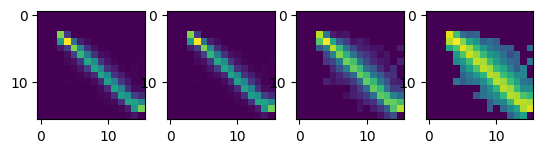

In [14]:
fig, axs = plt.subplots(1,4)

axs[0].imshow(mixing_matrix)
axs[1].imshow(mixing_matrix_dilation1)
axs[2].imshow(mixing_matrix_dilation2)
axs[3].imshow(mixing_matrix_dilation5)

plt.show()

In [15]:
def add_row_starts(mat, bins):
    """
    Adds required starts of rows to the mixing matrix mat, according to provided bins
    """
    final_mat = np.zeros(shape=(mat.shape[0], mat.shape[1]+1))
    for i in range(mat.shape[0]):
        final_mat[i] = np.concat([[bins[i]], mat[i,:]])
    return final_mat

In [16]:
married_matrix_natsal = add_row_starts(mixing_matrix, age_bins)

In [17]:
with np.printoptions(suppress=True):
    print(np.array2string(married_matrix_natsal, separator=', ', precision=3, max_line_width=1_000).replace("\n", ""))

[[ 0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ], [ 5.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ], [10.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ], [15.   ,  0.   ,  0.   ,  0.   ,  0.565,  0.115,  0.004,  0.001,  0.002,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ], [20.   ,  0.   ,  0.   ,  0.   ,  0.384,  0.698,  0.252,  0.059,  0.023,  0.002,  0.004,  0.001,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ], [25.   ,  0.   ,  0.   ,  0.   ,  0.051,  0.132,  0.562,  0.316,  0.096,  0.03 ,  0.007,  0.004,  0.002,  0.002,  0.   ,  0.   ,  0.004], [30.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.031,  0.137,  0.456,  0.29 ,  0.099,  0.03 ,  0.017,  0.005,  0.001,  0.003,  0.   ,  0.   ], [35.   ,  0.   ,  0.   ,  0.   , 

In [18]:
#Looking at the mixing matrix from https://doi.org/10.1016/j.epidem.2018.03.004
#potentially as general sexual mixing data this could accoutn for a casual layer and then the above for a married layer hmm. unless this is where sophie got her stuff from

casual_literature = [[	0,	0,	0,	0,	0,	        0,	0,	0,	0,	0,	0,	0],
                     [	0,	0,	0,	0,	0,	        0,	0,	0,	0,	0,	0,	0],  
                     [	0,	0,	0,	0,	0,	        0,	0,	0,	0,	0,	0,	0],  
                     [	0,	0,	0,	60.4,	58.9,	16,	3,	0.5,	0.1,	0,	0,	0],  
                       [0,	0,	0,	23.8,	71.1,	45.6,	17.2,	5.2,	1.4,	0.3,	0.1,	0], 
                           [	0,	0,	0,	3.2,	25.3,	34.6,	23.8,	11.5,	4.6,	1.7,	0.6,	0.2], 
                               [	0,	0,	0,	0.3,	5.9,	15.6,	18.6,	14.5,	8.3,	3.9,	1.6,	0.6],
                                       [	0,	0,	0,	0,	1.2,	    5.5,	10.2,	12.6,	11.1,	7.2,	3.6,	1.4],  
                                         [	0,	0,	0,	0,	0.2,	    1.6,	4.3,	7.7,	10.2,	9.9,	6.6,	3.1],  
                                           [	0,	0,	0,	0,	0,	        0.4,	1.5,	3.3,	6.1,	8.9,	9.2,	5.7],   
                                             [	0,	0,	0,	0,	0,	        0.1,	0.4,	1.1,	2.4,	4.8,	7.8,	8.2],  
                                                 [	0,	0,	0,	0,	0,	        0,	0.1,	0.3,	0.7,	1.6,	3.5,	6.5]]
casual_literature = np.array(casual_literature)
casual_literature = casual_literature / casual_literature.sum(axis=0, keepdims=True)
casual_literature = np.nan_to_num(casual_literature)


#Extend matrix to include 60,65,70,75 age bins (by filling with zeroes as sexual encounters at this age have negligable (likely no) impact on our modelled output, and besides can be expected to have relatively low occurance rate also)
casual_literature = np.pad(casual_literature, ((0, 4), (0, 4)), mode='constant')

casual_literature = add_row_starts(casual_literature, age_bins)

with np.printoptions(suppress=True):
    print(np.array2string(casual_literature, separator=', ', precision=3, max_line_width=1_000).replace("\n", ""))

[[ 0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ], [ 5.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ], [10.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ], [15.   ,  0.   ,  0.   ,  0.   ,  0.689,  0.362,  0.134,  0.038,  0.009,  0.002,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ], [20.   ,  0.   ,  0.   ,  0.   ,  0.271,  0.437,  0.382,  0.217,  0.092,  0.031,  0.008,  0.003,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ], [25.   ,  0.   ,  0.   ,  0.   ,  0.036,  0.156,  0.29 ,  0.301,  0.203,  0.102,  0.044,  0.018,  0.008,  0.   ,  0.   ,  0.   ,  0.   ], [30.   ,  0.   ,  0.   ,  0.   ,  0.003,  0.036,  0.131,  0.235,  0.256,  0.185,  0.102,  0.048,  0.023,  0.   ,  0.   ,  0.   ,  0.   ], [35.   ,  0.   ,  0.   ,  0.   , 

C:\Users\richa\AppData\Local\Temp\ipykernel_22424\70435974.py:17: RuntimeWarning: invalid value encountered in divide
  casual_literature = casual_literature / casual_literature.sum(axis=0, keepdims=True)


In [19]:
married_matrix_s = [        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],        [5, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],        [10, 0, 0, 0.08, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],        [15, 0, 0, 0.08, 0.1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],        [20, 0, 0, 0, 0, 0.6, 2, 0.2, 0.1, 0, 0, 0, 0, 0, 0, 0, 0],        [25, 0, 0, 0, 0, 0.6, 1, 2, 0.4, 0.1, 0, 0, 0, 0, 0, 0, 0],        [30, 0, 0, 0, 0, 0.5, 0.5, 2, 1, 0.5, 0.1, 0, 0, 0, 0, 0, 0],        [35, 0, 0, 0, 0, 1, 0.5, 1, 2, 1, 0.5, 0.2, 0, 0, 0, 0, 0],        [40, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0.5, 0.3, 0.1, 0, 0, 0, 0],        [45, 0, 0, 0, 0, 0.1, 1, 2, 2, 2, 1, 0.5, 0.2, 0.08, 0, 0, 0],        [50, 0, 0, 0, 0, 0, 0.1, 1, 2, 3, 2, 2, 0.5, 0.2, 0.05, 0, 0],        [55, 0, 0, 0, 0, 0, 0, 0.1, 1, 2, 3, 3, 2, 1, 0.3, 0.1, 0.1],        [60, 0, 0, 0, 0, 0, 0, 0.1, 0.5, 1, 2, 3, 3, 2, 0.5, 0.3, 0.1],        [65, 0, 0, 0, 0, 0, 0, 0, 0.5, 1, 2, 2, 3, 3, 2, 1, 0.2],        [70, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0.5, 1, 2, 3, 3, 2, 1],        [75, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 3],    ]
casual_matrix_s = [[0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0],        [5,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0],        [10,0,0,0,0.2,0.1,0.05,0,0,0,0,0,0,0,0,0,0],        [15,0,0,1,2,3,2,1,0.5,0,0,0,0,0,0,0,0],        [20,0,0,0.15,2,3,2,2,1,0.15,0,0,0,0,0,0,0],        [25,0,0,0.15,0.25,1,2,2,1,1,0,0,0,0,0,0,0],        [30,0,0,0,0,0.5,0.5,2,1,0.15,0,0,0,0,0,0,0],        [35,0,0,0,0,1,0.5,1,2,1,0.5,0,0,0,0,0,0],        [40,0,0,0,0,1,1,1,1,1,0.5,0.25,0,0,0,0,0],        [45,0,0,0,0,0.15,1,2,2,2,1,0.5,0.2,0.1,0,0,0],        [50,0,0,0,0,0,0.15,1,2,3,2,2,0.5,0.2,0.05,0,0],        [55,0,0,0,0,0,0,0.15,1,2,3,3,2,1,0.25,0.1,0.1],        [60,0,0,0,0,0,0,0.15,0.15,1,2,3,3,2,0.5,0.25,0.1],        [65,0,0,0,0,0,0,0,0,0,1,1,2,2,1,0.5,0],        [70,0,0,0,0,0,0,0,0,0,0,0,0,0.8,1,0.7,0.5],        [75,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.1,0.25]    ]

married_matrix_natsal = [[ 0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ], [ 5.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ], [10.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ], [15.   ,  0.   ,  0.   ,  0.   ,  0.565,  0.115,  0.004,  0.001,  0.002,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ], [20.   ,  0.   ,  0.   ,  0.   ,  0.384,  0.698,  0.252,  0.059,  0.023,  0.002,  0.004,  0.001,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ], [25.   ,  0.   ,  0.   ,  0.   ,  0.051,  0.132,  0.562,  0.316,  0.096,  0.03 ,  0.007,  0.004,  0.002,  0.002,  0.   ,  0.   ,  0.004], [30.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.031,  0.137,  0.456,  0.29 ,  0.099,  0.03 ,  0.017,  0.005,  0.001,  0.003,  0.   ,  0.   ], [35.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.018,  0.032,  0.112,  0.422,  0.349,  0.107,  0.038,  0.01 ,  0.004,  0.002,  0.   ,  0.007], [40.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.009,  0.042,  0.128,  0.412,  0.326,  0.095,  0.054,  0.011,  0.002,  0.011,  0.   ], [45.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.002,  0.009,  0.031,  0.078,  0.402,  0.331,  0.107,  0.057,  0.016,  0.013,  0.   ], [50.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.006,  0.002,  0.005,  0.007,  0.02 ,  0.089,  0.399,  0.309,  0.111,  0.047,  0.007,  0.004], [55.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.005,  0.021,  0.085,  0.402,  0.306,  0.098,  0.02 ,  0.02 ], [60.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.001,  0.005,  0.01 ,  0.021,  0.093,  0.391,  0.349,  0.137,  0.086], [65.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.001,  0.01 ,  0.014,  0.101,  0.417,  0.406,  0.33 ], [70.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.002,  0.   ,  0.004,  0.016,  0.054,  0.365,  0.549], [75.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.002,  0.013,  0.041,  0.   ]]
casual_literature = [[ 0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ], [ 5.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ], [10.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ], [15.   ,  0.   ,  0.   ,  0.   ,  0.689,  0.362,  0.134,  0.038,  0.009,  0.002,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ], [20.   ,  0.   ,  0.   ,  0.   ,  0.271,  0.437,  0.382,  0.217,  0.092,  0.031,  0.008,  0.003,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ], [25.   ,  0.   ,  0.   ,  0.   ,  0.036,  0.156,  0.29 ,  0.301,  0.203,  0.102,  0.044,  0.018,  0.008,  0.   ,  0.   ,  0.   ,  0.   ], [30.   ,  0.   ,  0.   ,  0.   ,  0.003,  0.036,  0.131,  0.235,  0.256,  0.185,  0.102,  0.048,  0.023,  0.   ,  0.   ,  0.   ,  0.   ], [35.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.007,  0.046,  0.129,  0.222,  0.247,  0.188,  0.109,  0.054,  0.   ,  0.   ,  0.   ,  0.   ], [40.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.001,  0.013,  0.054,  0.136,  0.227,  0.258,  0.2  ,  0.121,  0.   ,  0.   ,  0.   ,  0.   ], [45.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.003,  0.019,  0.058,  0.136,  0.232,  0.279,  0.222,  0.   ,  0.   ,  0.   ,  0.   ], [50.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.001,  0.005,  0.019,  0.053,  0.125,  0.236,  0.319,  0.   ,  0.   ,  0.   ,  0.   ], [55.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.001,  0.005,  0.016,  0.042,  0.106,  0.253,  0.   ,  0.   ,  0.   ,  0.   ], [60.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ], [65.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ], [70.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ], [75.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ]]


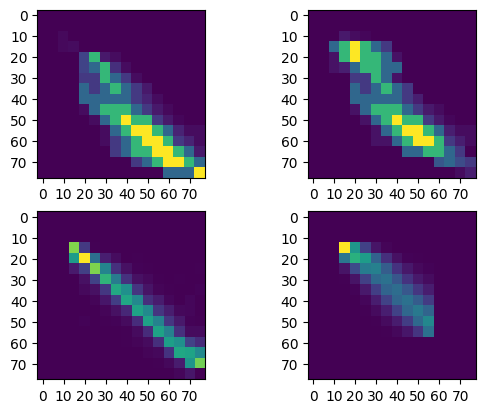

In [20]:
fig, axs = plt.subplots(2,2)

axs[0,0].imshow(np.array(married_matrix_s)[:,1:])
axs[0,1].imshow(np.array(casual_matrix_s)[:,1:])
axs[1,0].imshow(np.array(married_matrix_natsal)[:,1:])
axs[1,1].imshow(np.array(casual_literature)[:,1:])

for i in range(2):
    for j in range(2):
        axs[i,j].set_xticks([0,2,4,6,8,10,12,14],[0,10,20,30,40,50,60,70])
        axs[i,j].set_yticks([0,2,4,6,8,10,12,14],[0,10,20,30,40,50,60,70])



plt.show()

# Find debut distributions

In [21]:
#Extract raw data
males = df[df['rsex']==1]
females = df[df['rsex']==2]

debuts_m = males[males['afsexall']<96]['afsexall'] #for simplicity, filter out all cases where answer is 'not happened yet' or 'refused'/'not answered'
debuts_f = females[females['afsexall']<96]['afsexall']



debuts_m = debuts_m[debuts_m>10] #filter out debuts <=10 from our modelling for taking logs and avoiding likely erroneous data
debuts_f = debuts_f[debuts_f>10]




<scipy.stats._continuous_distns.exponnorm_gen object at 0x000001EAFA23EBC0>: (np.float64(2.0408916163272464), np.float64(14.86159360812454), np.float64(1.2446420329339398))
<scipy.stats._continuous_distns.alpha_gen object at 0x000001EAFA23EC20>: (np.float64(5.618387159312963), np.float64(3.203780507580624), np.float64(76.98433520115125))
<scipy.stats._continuous_distns.norm_gen object at 0x000001EAFA23CD60>: (np.float64(17.40177918596149), np.float64(2.9399368387978195))
<scipy.stats._continuous_distns.lognorm_gen object at 0x000001EAFA29D720>: (np.float64(0.32524556671986043), 9.12174661160612, np.float64(7.841656969362918))
<scipy.stats._continuous_distns.expon_gen object at 0x000001EAFA23FF10>: (11.0, 6.401779185961491)
<scipy.stats._continuous_distns.gamma_gen object at 0x000001EAFA273190>: (np.float64(0.8076121526604536), np.float64(10.999999999999998), np.float64(2.3053414919370603))
exponnorm: AIC=38277.87
alpha: AIC=38479.63
lognorm: AIC=38659.77
norm: AIC=40990.12
expon: AIC=4

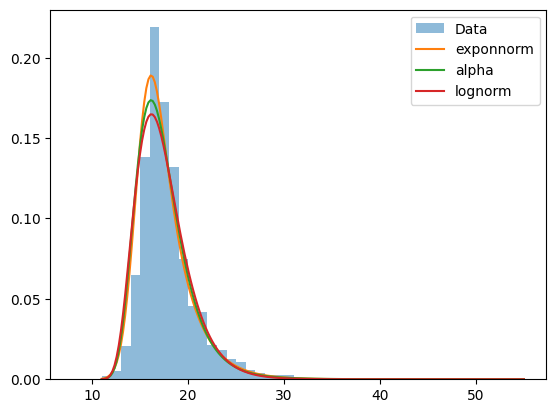

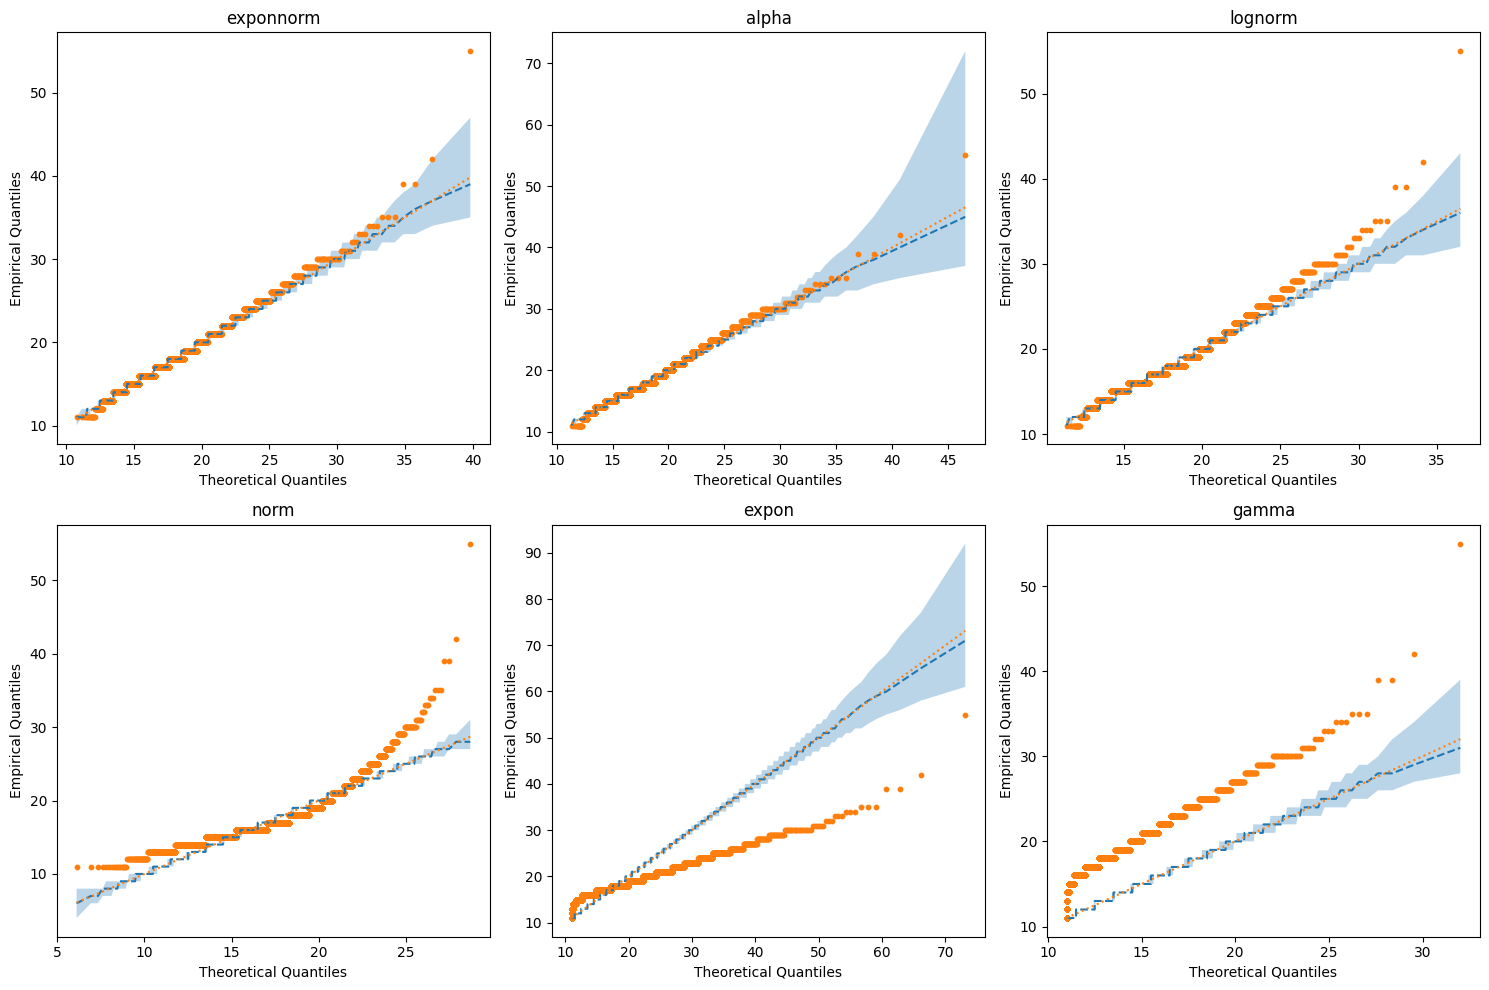

In [22]:
#Fit data for FEMALE

distributions = [
    stats.exponnorm,
    stats.alpha,
    stats.norm,
    stats.lognorm,
    stats.expon,
    stats.gamma,
]

data = debuts_f

distributions = distributions

results = []

for dist in distributions:
    try:
        # Fit distribution
        params = dist.fit(data)
        print(f'{dist}: {params}')

        # Log-likelihood
        loglik = np.sum(dist.logpdf(data, *params))

        # Number of parameters
        k = len(params)

        # AIC (Akaike Information Criterion)
        aic = 2 * k - 2 * loglik

        results.append((dist.name, aic, params))
    except Exception as e:
        print(f"{dist.name} failed: {e}")

# Sort by AIC (lower is better)
results.sort(key=lambda x: x[1])

for name, aic, params in results:
    print(f"{name}: AIC={aic:.2f}")


#Histogram
x = np.linspace(min(data), max(data), 200)

plt.hist(data, bins=np.arange(8,40,1), density=True, alpha=0.5, label="Data")

for name, _, params in results[:3]:  
    dist = getattr(stats, name)
    plt.plot(x, dist.pdf(x, *params), label=name)

plt.legend()
plt.show()

# ---- QQ plot with simulation bands ----
n_sim = 10_000  # increase for smoother bands
data = debuts_f
n=len(data)

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = [axes[0,0], axes[0,1], axes[0,2], axes[1,0], axes[1,1], axes[1,2]]

for ax, (name, _, params) in zip(axes, results[:6]):
    dist = getattr(stats, name)

    sorted_data = np.sort(data)
    probs = (np.arange(1, n+1) - 0.5) / n

    # Theoretical quantiles
    theoretical_q = dist.ppf(probs, *params)

    # --- Simulate envelopes ---
    sim_quantiles = np.zeros((n_sim, n))

    for i in range(n_sim):
        sim_sample = dist.rvs(*params, size=n)
        sim_sample = np.round(sim_sample)
        sim_quantiles[i, :] = np.sort(sim_sample)

    lower = np.percentile(sim_quantiles, 2.5, axis=0)
    upper = np.percentile(sim_quantiles, 97.5, axis=0)
    median = np.percentile(sim_quantiles, 50, axis=0)

    # --- Plot ---
    ax.fill_between(theoretical_q, lower, upper, alpha=0.3)
    ax.plot(theoretical_q, median, linestyle='--')
    ax.scatter(theoretical_q, sorted_data, s=10)

    # 45-degree reference
    ax.plot(theoretical_q, theoretical_q, linestyle=':')

    ax.set_title(name)
    ax.set_xlabel("Theoretical Quantiles")
    ax.set_ylabel("Empirical Quantiles")

plt.tight_layout()
plt.show()


<scipy.stats._continuous_distns.exponnorm_gen object at 0x000001EAFA23EBC0>: (np.float64(1.7915590056501285), np.float64(14.599511148535075), np.float64(1.4554358347246472))
<scipy.stats._continuous_distns.alpha_gen object at 0x000001EAFA23EC20>: (np.float64(5.820413155751893), np.float64(1.381598872288413), np.float64(89.09293081903846))
<scipy.stats._continuous_distns.norm_gen object at 0x000001EAFA23CD60>: (np.float64(17.207018162581555), np.float64(3.2112744615303823))
<scipy.stats._continuous_distns.lognorm_gen object at 0x000001EAFA29D720>: (np.float64(0.3249923622647172), 8.281760878550369, np.float64(8.4520657241918))
<scipy.stats._continuous_distns.expon_gen object at 0x000001EAFA23FF10>: (11.0, 6.207018162581555)
<scipy.stats._continuous_distns.gamma_gen object at 0x000001EAFA273190>: (np.float64(5.991726094429984), np.float64(9.96212315414372), np.float64(1.2091498215271481))
exponnorm: AIC=27308.65
alpha: AIC=27424.09
lognorm: AIC=27560.21
gamma: AIC=27749.07
norm: AIC=2932

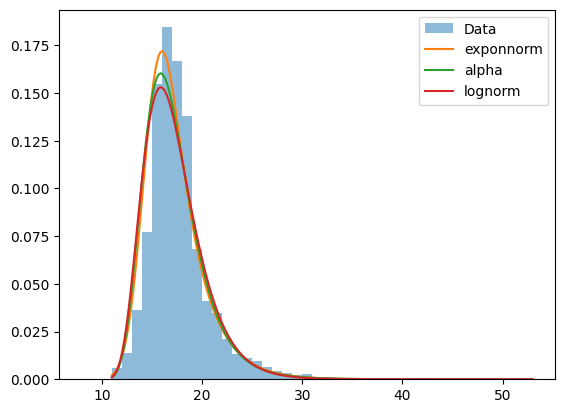

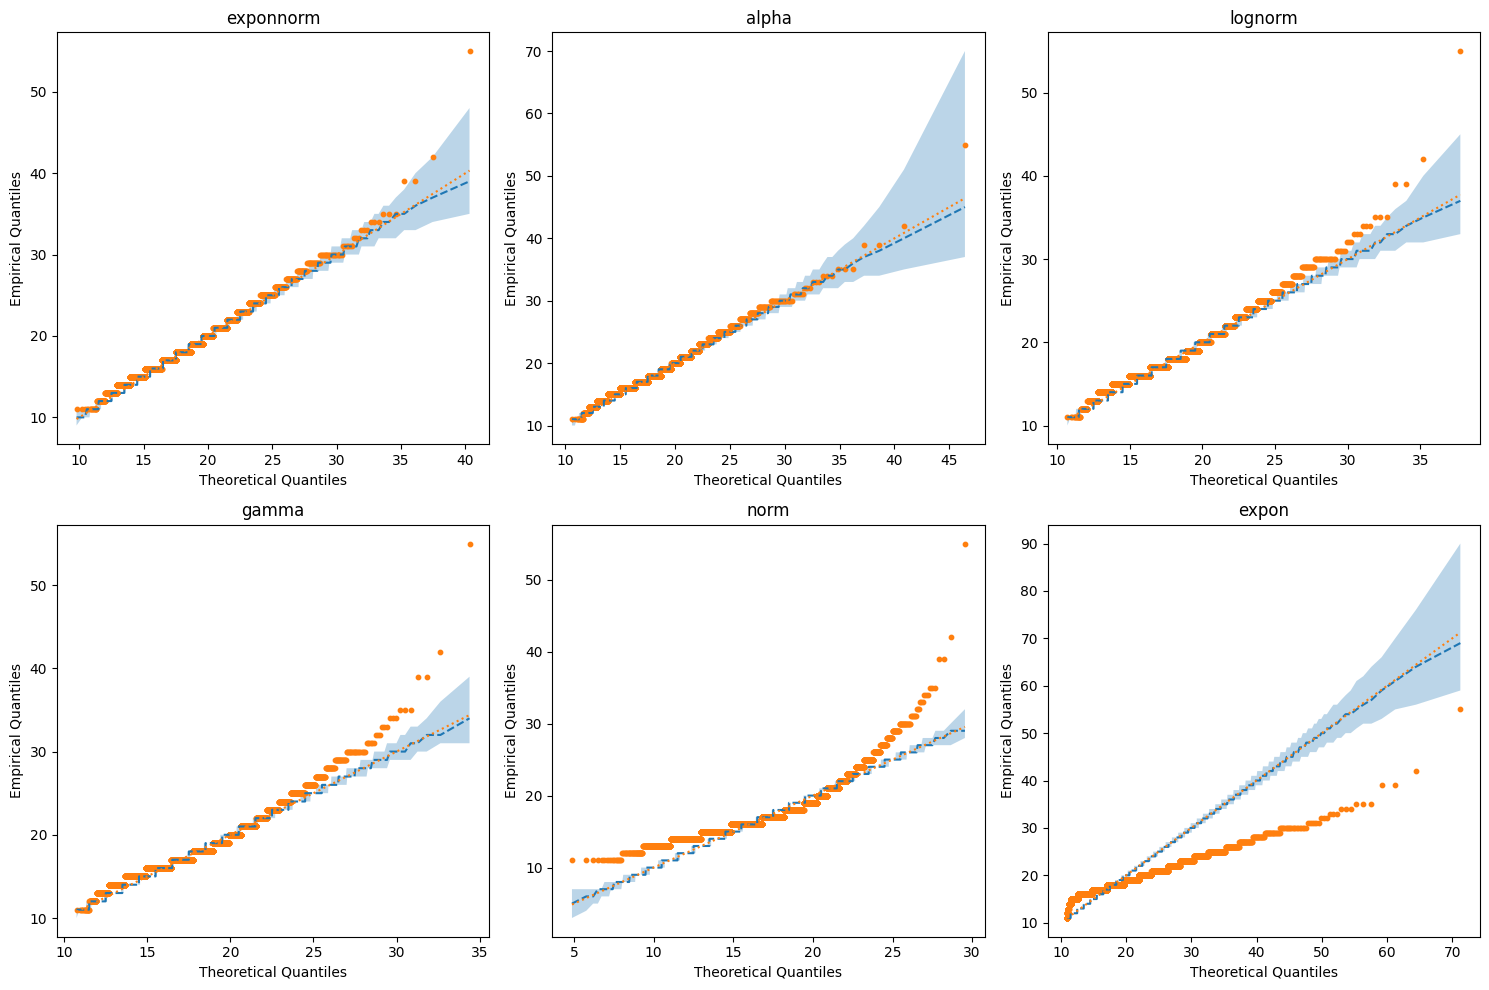

In [23]:
#Fit data for MALE

distributions = [
    stats.exponnorm,
    stats.alpha,
    stats.norm,
    stats.lognorm,
    stats.expon,
    stats.gamma,
]

data = debuts_m

distributions = distributions 

results = []

for dist in distributions:
    try:
        # Fit distribution
        params = dist.fit(data)
        print(f'{dist}: {params}')

        # Log-likelihood
        loglik = np.sum(dist.logpdf(data, *params))

        # Number of parameters
        k = len(params)

        # AIC (Akaike Information Criterion)
        aic = 2 * k - 2 * loglik

        results.append((dist.name, aic, params))
    except Exception as e:
        print(f"{dist.name} failed: {e}")

# Sort by AIC (lower is better)
results.sort(key=lambda x: x[1])

for name, aic, params in results:
    print(f"{name}: AIC={aic:.2f}")


#Histogram
x = np.linspace(min(data), max(data), 200)

plt.hist(data, bins=np.arange(8,40,1), density=True, alpha=0.5, label="Data")

for name, _, params in results[:3]:  # top 3
    dist = getattr(stats, name)
    plt.plot(x, dist.pdf(x, *params), label=name)

plt.legend()
plt.show()

# ---- QQ plot with simulation bands ----
n_sim = 10_000  # increase for smoother bands
data = debuts_f
n=len(data)

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = [axes[0,0], axes[0,1], axes[0,2], axes[1,0], axes[1,1], axes[1,2]]

for ax, (name, _, params) in zip(axes, results[:6]):
    dist = getattr(stats, name)

    sorted_data = np.sort(data)
    probs = (np.arange(1, n+1) - 0.5) / n

    # Theoretical quantiles
    theoretical_q = dist.ppf(probs, *params)

    # --- Simulate envelopes ---
    sim_quantiles = np.zeros((n_sim, n))

    for i in range(n_sim):
        sim_sample = dist.rvs(*params, size=n)
        sim_sample = np.round(sim_sample)
        sim_quantiles[i, :] = np.sort(sim_sample)

    lower = np.percentile(sim_quantiles, 2.5, axis=0)
    upper = np.percentile(sim_quantiles, 97.5, axis=0)
    median = np.percentile(sim_quantiles, 50, axis=0)

    # --- Plot ---
    ax.fill_between(theoretical_q, lower, upper, alpha=0.3)
    ax.plot(theoretical_q, median, linestyle='--')
    ax.scatter(theoretical_q, sorted_data, s=10)

    # 45-degree reference
    ax.plot(theoretical_q, theoretical_q, linestyle=':')

    ax.set_title(name)
    ax.set_xlabel("Theoretical Quantiles")
    ax.set_ylabel("Empirical Quantiles")

plt.tight_layout()
plt.show()


# Heterosexual degree distribution and concurrency

This section uses the Natsal heterosexual partner-count variables as an empirical degree distribution for a heterosexual sexual-contact layer.

Suggested interpretation:
Suggested interpretation:
- `het1yr` is our starting point for an annual active-partnership degree distribution.
    - 0 if missing & (everhet=0 | hetlife=0 | het5yrs=0), -1: not applicable else if scelign3=2, 999: not answered
- `het5yrs` and `hetlife` are also useful
- `het5yrs`:
    -  0 if missing & (everhet=0 | hetlife=0), 9995: at least one, 9999: not answered,  -1: not applicable else if scelign3=2
- `hetlife`:
    -  0 or if missing & everhet=0, 9995: at least one, -1: not applicable else if scelign3=2  

- `hetnewp`/`hetnonew` maybe useful??
- `mrpconcly`, `mrpconcl5y`, and/or `overlp5y` are useful for partnership concurrency/overlap.

The code below is deliberately defensive: it checks which variables are present in the uploaded SPSS file, cleans common Natsal missing-value codes, uses `total_wt` for weighted estimates, and then plots empirical degree distributions plus simple Poisson and negative-binomial fits. The negative binomial is fitted by weighted moments, which is usually more appropriate than Poisson when the degree distribution is overdispersed.

In [6]:
# -----------------------------
# Helpers for weighted counts
# -----------------------------

from collections import OrderedDict
import pandas as pd


def first_existing_col(df, candidates, required=False):
    """Return the first variable from candidates that exists in df."""
    for col in candidates:
        if col in df.columns:
            return col
    if required:
        raise KeyError(f"None of these columns were found: {candidates}")
    return None


def clean_count(s, missing_codes=(-1, 95, 96, 97, 98, 99, 999, 9999), max_reasonable=None):
    """Clean a Natsal count-like variable and return numeric counts.

    Many Natsal variables use negative values for not-applicable and high values
    such as 99/999/9999 for missing/refused/not answered. For partner-count
    variables, valid values should be non-negative integers.
    """
    x = pd.to_numeric(s, errors='coerce')
    x = x.mask(x.isin(missing_codes))
    x = x.mask(x < 0)
    if max_reasonable is not None:
        x = x.mask(x > max_reasonable)
    return x


def weighted_mean(x, w):
    x = np.asarray(x, dtype=float)
    w = np.asarray(w, dtype=float)
    mask = np.isfinite(x) & np.isfinite(w) & (w > 0)
    if mask.sum() == 0:
        return np.nan
    return np.sum(w[mask] * x[mask]) / np.sum(w[mask])


def weighted_var(x, w):
    mu = weighted_mean(x, w)
    x = np.asarray(x, dtype=float)
    w = np.asarray(w, dtype=float)
    mask = np.isfinite(x) & np.isfinite(w) & (w > 0)
    if mask.sum() == 0:
        return np.nan
    return np.sum(w[mask] * (x[mask] - mu)**2) / np.sum(w[mask])


def weighted_pmf(x, w, max_degree=20):
    """Return a weighted PMF for integer counts 0..max_degree plus an overflow bin."""
    tmp = pd.DataFrame({'degree': x, 'weight': w}).dropna()
    tmp = tmp[(tmp['weight'] > 0) & (tmp['degree'] >= 0)]
    tmp['degree'] = tmp['degree'].round().astype(int)
    tmp['degree_plot'] = tmp['degree'].clip(upper=max_degree)
    pmf = tmp.groupby('degree_plot')['weight'].sum().reindex(range(max_degree + 1), fill_value=0.0)
    pmf = pmf / pmf.sum()
    return pmf


def describe_weighted_counts(df, count_col, weight_col='total_wt', group_col='sex_label'):
    rows = []
    for group, g in df.dropna(subset=[count_col]).groupby(group_col):
        x = g[count_col].to_numpy()
        w = g[weight_col].to_numpy()
        rows.append({
            group_col: group,
            'n_unweighted': len(g),
            'weighted_N': np.sum(w),
            'weighted_mean_degree': weighted_mean(x, w),
            'weighted_variance': weighted_var(x, w),
            'weighted_prop_zero': weighted_mean((x == 0).astype(float), w),
            'weighted_prop_2plus': weighted_mean((x >= 2).astype(float), w),
            'weighted_prop_5plus': weighted_mean((x >= 5).astype(float), w),
        })
    return pd.DataFrame(rows)

In [7]:
# -----------------------------
# Select Natsal variables
# -----------------------------

weight_col = first_existing_col(df, ['total_wt', 'final_wt'], required=True)
sex_col = first_existing_col(df, ['rsex'], required=True)
age_col = first_existing_col(df, ['dage'], required=True)

# Partner-count candidates. het1yr is the annual active degree distribution.
count_candidates = OrderedDict({
    'annual_degree_het1yr': ['het1yr'],
    'five_year_degree_het5yrs': ['het5yrs'],
    'lifetime_degree_hetlife': ['hetlife'],
    'new_partners_last_year_hetnewp': ['hetnewp', 'hetnonew'],
})

available_count_cols = OrderedDict()
for nice_name, candidates in count_candidates.items():
    col = first_existing_col(df, candidates)
    if col is not None:
        available_count_cols[nice_name] = col

print('Using weight column:', weight_col)
print('Available heterosexual partner-count variables:')
for nice_name, col in available_count_cols.items():
    print(f'  {nice_name}: {col}')

# Concurrency/overlap variables. Prefer last-year concurrency for an annual network layer.
concurrency_candidates = OrderedDict({
    'concurrent_last_year': ['mrpconcly', 'concurtly'],
    'concurrent_last_5_years': ['mrpconcl5y', 'overlp5y', 'concurt'],
})
available_concurrency_cols = OrderedDict()
for nice_name, candidates in concurrency_candidates.items():
    col = first_existing_col(df, candidates)
    if col is not None:
        available_concurrency_cols[nice_name] = col

print('\nAvailable heterosexual concurrency/overlap variables:')
for nice_name, col in available_concurrency_cols.items():
    print(f'  {nice_name}: {col}')

# Optional: inspect value labels, if pyreadstat metadata is available.
try:
    labels = meta.get('variable_value_labels', {})
    for col in list(available_count_cols.values()) + list(available_concurrency_cols.values()):
        if col in labels:
            print(f'\nValue labels for {col}:')
            print(labels[col])
except Exception as e:
    print('Could not print value labels:', e)

Using weight column: total_wt
Available heterosexual partner-count variables:
  annual_degree_het1yr: het1yr
  five_year_degree_het5yrs: het5yrs
  lifetime_degree_hetlife: hetlife
  new_partners_last_year_hetnewp: hetnewp

Available heterosexual concurrency/overlap variables:
  concurrent_last_year: mrpconcly
  concurrent_last_5_years: mrpconcl5y

Value labels for het1yr:
{-1.0: 'Not applicable', 995.0: 'At least one', 996.0: 'At least two', 997.0: 'At least three', 999.0: 'Not answered'}

Value labels for het5yrs:
{-1.0: 'Not applicable', 9995.0: 'At least one', 9996.0: 'At least two', 9997.0: 'At least three', 9999.0: 'Not answered'}

Value labels for hetlife:
{-1.0: 'Not applicable', 9995.0: 'At least one', 9996.0: 'At least two', 9997.0: 'At least three', 9999.0: 'Not answered'}

Value labels for hetnewp:
{-1.0: 'Not applicable', 1.0: 'Yes', 2.0: 'No', 9.0: 'Not answered'}

Value labels for mrpconcly:
{-1.0: 'Not applicable', 0.0: '2+ partners in last year (serial monogamy)', 1.0: 

In [9]:
# -----------------------------
# Build analysis frame
# -----------------------------

het_degree = df[[sex_col, age_col, weight_col] + list(available_count_cols.values()) + list(available_concurrency_cols.values())].copy()
het_degree = het_degree.rename(columns={sex_col: 'rsex', age_col: 'age', weight_col: 'weight'})

het_degree['sex_label'] = het_degree['rsex'].map({1: 'Male', 2: 'Female'})
het_degree = het_degree[het_degree['sex_label'].notna()].copy()
het_degree = het_degree[(het_degree['age'] >= 16) & (het_degree['age'] <= 74)].copy()

# Clean partner-count variables. Annual counts are restricted to a smaller plausible range;
# lifetime counts keep a wider range.
cleaned_count_cols = []
for nice_name, col in available_count_cols.items():
    if 'lifetime' in nice_name:
        max_reasonable = 10000
    elif 'five_year' in nice_name:
        max_reasonable = 1000
    else:
        max_reasonable = 365
    clean_col = f'{col}_clean'
    het_degree[clean_col] = clean_count(het_degree[col], max_reasonable=max_reasonable)
    cleaned_count_cols.append(clean_col)
    print(f'{col}: kept {het_degree[clean_col].notna().sum()} valid rows')

# Clean concurrency variables. This maps common Natsal yes/no codings:
#   0/1 derived variables -> 1=yes, 0=no
#   1/2 questionnaire variables -> 1=yes, 2=no
# Check printed value labels above if you want to verify.
def clean_yes_no(s):
    x = pd.to_numeric(s, errors='coerce')
    vals = set(x.dropna().unique())
    x = x.mask(x.isin([-1, 8, 9, 98, 99, 999, 9999]))
    vals_clean = set(x.dropna().unique())
    if vals_clean.issubset({0, 1}):
        return x
    if vals_clean.issubset({1, 2}):
        return x.map({1: 1, 2: 0})
    # Fallback: keep 0/1 and set everything else missing.
    return x.where(x.isin([0, 1]))

cleaned_conc_cols = []
for nice_name, col in available_concurrency_cols.items():
    clean_col = f'{col}_clean'
    het_degree[clean_col] = clean_yes_no(het_degree[col])
    cleaned_conc_cols.append(clean_col)
    print(f'{col}: kept {het_degree[clean_col].notna().sum()} valid rows')

# Age bands for prevalence plots.
age_bins_degree = [16, 20, 25, 35, 45, 55, 65, 75]
age_labels_degree = ['16-19', '20-24', '25-34', '35-44', '45-54', '55-64', '65-74']
het_degree['age_group'] = pd.cut(
    het_degree['age'], bins=age_bins_degree, labels=age_labels_degree,
    right=False, include_lowest=True
)

het_degree.head()

het1yr: kept 14588 valid rows
het5yrs: kept 14627 valid rows
hetlife: kept 14803 valid rows
hetnewp: kept 9509 valid rows
mrpconcly: kept 1658 valid rows
mrpconcl5y: kept 5037 valid rows


,rsex,age,weight,het1yr,het5yrs,hetlife,hetnewp,mrpconcly,mrpconcl5y,sex_label,het1yr_clean,het5yrs_clean,hetlife_clean,hetnewp_clean,mrpconcly_clean,mrpconcl5y_clean,age_group
0,1.0,25.0,0.460514,1.0,1.0,1.0,1.0,-1.0,-1.0,Male,1.0,1.0,1.0,1.0,NaN,NaN,25-34
1,2.0,30.0,1.788954,1.0,1.0,1.0,2.0,-1.0,-1.0,Female,1.0,1.0,1.0,2.0,NaN,NaN,25-34
2,1.0,29.0,1.381543,1.0,2.0,3.0,2.0,-1.0,0.0,Male,1.0,2.0,3.0,2.0,NaN,0.0,25-34
3,2.0,27.0,0.739011,1.0,4.0,17.0,1.0,-1.0,0.0,Female,1.0,4.0,17.0,1.0,NaN,0.0,25-34
4,2.0,41.0,1.923944,1.0,1.0,3.0,2.0,-1.0,-1.0,Female,1.0,1.0,3.0,2.0,NaN,NaN,35-44


In [10]:
# -----------------------------
# Weighted heterosexual degree distribution
# -----------------------------

# Use annual heterosexual partners as the main degree distribution when available.
main_degree_col = f"{available_count_cols.get('annual_degree_het1yr', next(iter(available_count_cols.values())))}_clean"
print('Main degree column:', main_degree_col)

summary_table = describe_weighted_counts(het_degree, main_degree_col, weight_col='weight', group_col='sex_label')
summary_table

Main degree column: het1yr_clean


,sex_label,n_unweighted,weighted_N,weighted_mean_degree,weighted_variance,weighted_prop_zero,weighted_prop_2plus,weighted_prop_5plus
0,Female,8540,7329.869230,1.042088,6.910590,0.222957,0.093244,0.017314
1,Male,6048,7180.665784,1.272877,4.723296,0.178818,0.149395,0.030489


In [7]:
# Plot empirical annual heterosexual degree distribution with Poisson and negative-binomial fits.
# The final bar is an overflow bin: max_degree+.

from scipy.special import gammaln


def negbin_params_moments(mu, var):
    """Method-of-moments NB parameters for scipy.stats.nbinom.

    scipy uses n=size and p=success probability, with mean=n*(1-p)/p.
    """
    if not np.isfinite(mu) or not np.isfinite(var) or mu <= 0 or var <= mu:
        return None
    n = mu**2 / (var - mu)
    p = n / (n + mu)
    return n, p


def plot_degree_fit_by_sex(data, count_col, max_degree=15):
    x_grid = np.arange(max_degree + 1)
    fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

    for ax, sex in zip(axes, ['Female', 'Male']):
        g = data[(data['sex_label'] == sex) & data[count_col].notna()].copy()
        x = g[count_col].round().astype(int).to_numpy()
        w = g['weight'].to_numpy()
        pmf = weighted_pmf(x, w, max_degree=max_degree)

        mu = weighted_mean(x, w)
        var = weighted_var(x, w)
        poisson_pmf = stats.poisson.pmf(x_grid, mu)

        ax.bar(x_grid, pmf.values, alpha=0.5, label='Weighted Natsal empirical')
        ax.plot(x_grid, poisson_pmf, marker='o', label=f'Poisson, mean={mu:.2f}')

        nb_params = negbin_params_moments(mu, var)
        if nb_params is not None:
            n, p = nb_params
            nb_pmf = stats.nbinom.pmf(x_grid, n, p)
            ax.plot(x_grid, nb_pmf, marker='o', label=f'NegBin, var={var:.2f}')

        ax.set_title(f'{sex}: heterosexual partners in last year')
        ax.set_xlabel(f'Number of partners, {max_degree}+ overflow')
        ax.set_ylabel('Weighted probability')
        ax.set_xticks(x_grid)
        ax.set_xticklabels([str(i) for i in range(max_degree)] + [f'{max_degree}+'])
        ax.legend()

    plt.tight_layout()
    plt.show()

plot_degree_fit_by_sex(het_degree, main_degree_col, max_degree=15)

NameError: name 'het_degree' is not defined

In [12]:
# -----------------------------
# Degree PMFs for simulation input
# -----------------------------

# These arrays can be used directly as empirical sampling probabilities.
# pmf[k] is P(degree=k), except the final element is P(degree>=max_degree).

max_degree_for_sim = 20
het_degree_pmf_by_sex = {}

for sex in ['Female', 'Male']:
    g = het_degree[(het_degree['sex_label'] == sex) & het_degree[main_degree_col].notna()]
    pmf = weighted_pmf(g[main_degree_col], g['weight'], max_degree=max_degree_for_sim)
    het_degree_pmf_by_sex[sex] = pmf.to_numpy()
    print(f'\n{sex} PMF, final bin is {max_degree_for_sim}+:')
    with np.printoptions(suppress=True, precision=4):
        print(het_degree_pmf_by_sex[sex])


def sample_heterosexual_degrees(n, sex, pmfs=het_degree_pmf_by_sex, max_degree=max_degree_for_sim, rng=None):
    """Sample annual heterosexual degree from the empirical Natsal PMF.

    The final PMF category is an overflow bin. Here, overflow is returned as
    max_degree. If you want to preserve a heavier tail, replace this with a
    parametric tail model or sample observed values conditional on >=max_degree.
    """
    if rng is None:
        rng = np.random.default_rng()
    support = np.arange(max_degree + 1)
    return rng.choice(support, size=n, p=pmfs[sex])


Female PMF, final bin is 20+:
[0.223  0.6838 0.0468 0.0191 0.01   0.0062 0.0035 0.002  0.0017 0.0008
 0.0009 0.0003 0.0005 0.     0.0001 0.0001 0.0001 0.0001 0.0001 0.
 0.001 ]

Male PMF, final bin is 20+:
[0.1788 0.6718 0.0702 0.0331 0.0156 0.0097 0.0046 0.0031 0.0025 0.0004
 0.0028 0.0005 0.0009 0.0005 0.0002 0.0014 0.0006 0.0002 0.     0.0001
 0.0031]


Concurrency column: mrpconcly_clean


,sex_label,age_group,weighted_concurrency_prevalence,weighted_N,n_unweighted
0,Female,16-19,0.443659,97.588780,188
1,Female,20-24,0.504375,122.135513,213
2,Female,25-34,0.515862,125.265455,265
3,Female,35-44,0.595672,64.552091,69
4,Female,45-54,0.822320,39.049044,38
5,Female,55-64,0.707455,10.351045,12
6,Female,65-74,0.479489,3.099723,3
7,Male,16-19,0.462681,117.022691,184
8,Male,20-24,0.459669,173.395847,223
9,Male,25-34,0.591712,196.203153,246


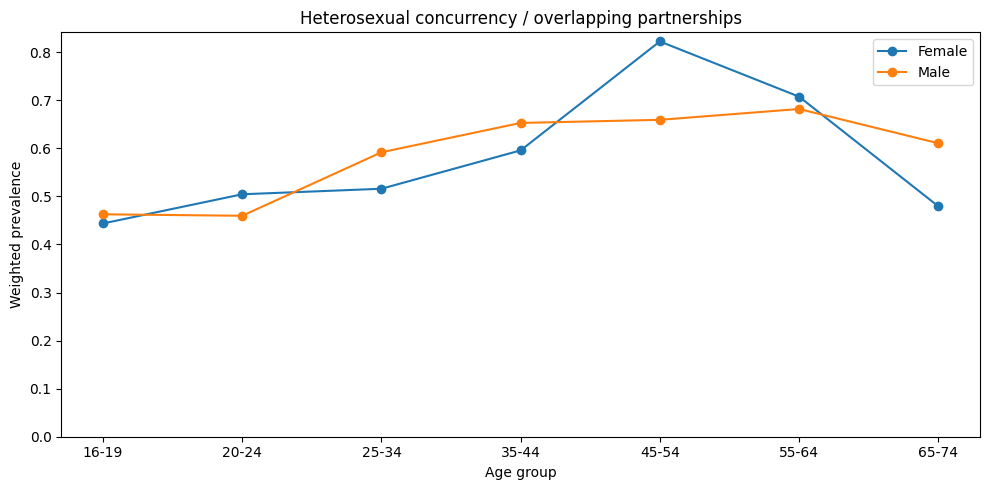

In [13]:
# -----------------------------
# Concurrency / overlapping partnerships
# -----------------------------

if len(cleaned_conc_cols) == 0:
    print('No concurrency/overlap variable found in this dataset.')
else:
    # Prefer annual concurrency if present, otherwise fall back to a last-5-year overlap/concurrency variable.
    conc_col = None
    for candidate in ['mrpconcly_clean', 'concurtly_clean', 'mrpconcl5y_clean', 'overlp5y_clean', 'concurt_clean']:
        if candidate in het_degree.columns:
            conc_col = candidate
            break
    print('Concurrency column:', conc_col)

    conc_summary = []
    for (sex, age_group), g in het_degree.dropna(subset=[conc_col, 'age_group']).groupby(['sex_label', 'age_group'], observed=True):
        conc_summary.append({
            'sex_label': sex,
            'age_group': age_group,
            'weighted_concurrency_prevalence': weighted_mean(g[conc_col], g['weight']),
            'weighted_N': g['weight'].sum(),
            'n_unweighted': len(g),
        })
    conc_summary = pd.DataFrame(conc_summary)
    display(conc_summary)

    fig, ax = plt.subplots(figsize=(10, 5))
    for sex in ['Female', 'Male']:
        tmp = conc_summary[conc_summary['sex_label'] == sex]
        ax.plot(tmp['age_group'].astype(str), tmp['weighted_concurrency_prevalence'], marker='o', label=sex)

    ax.set_ylim(bottom=0)
    ax.set_xlabel('Age group')
    ax.set_ylabel('Weighted prevalence')
    ax.set_title('Heterosexual concurrency / overlapping partnerships')
    ax.legend()
    plt.tight_layout()
    plt.show()

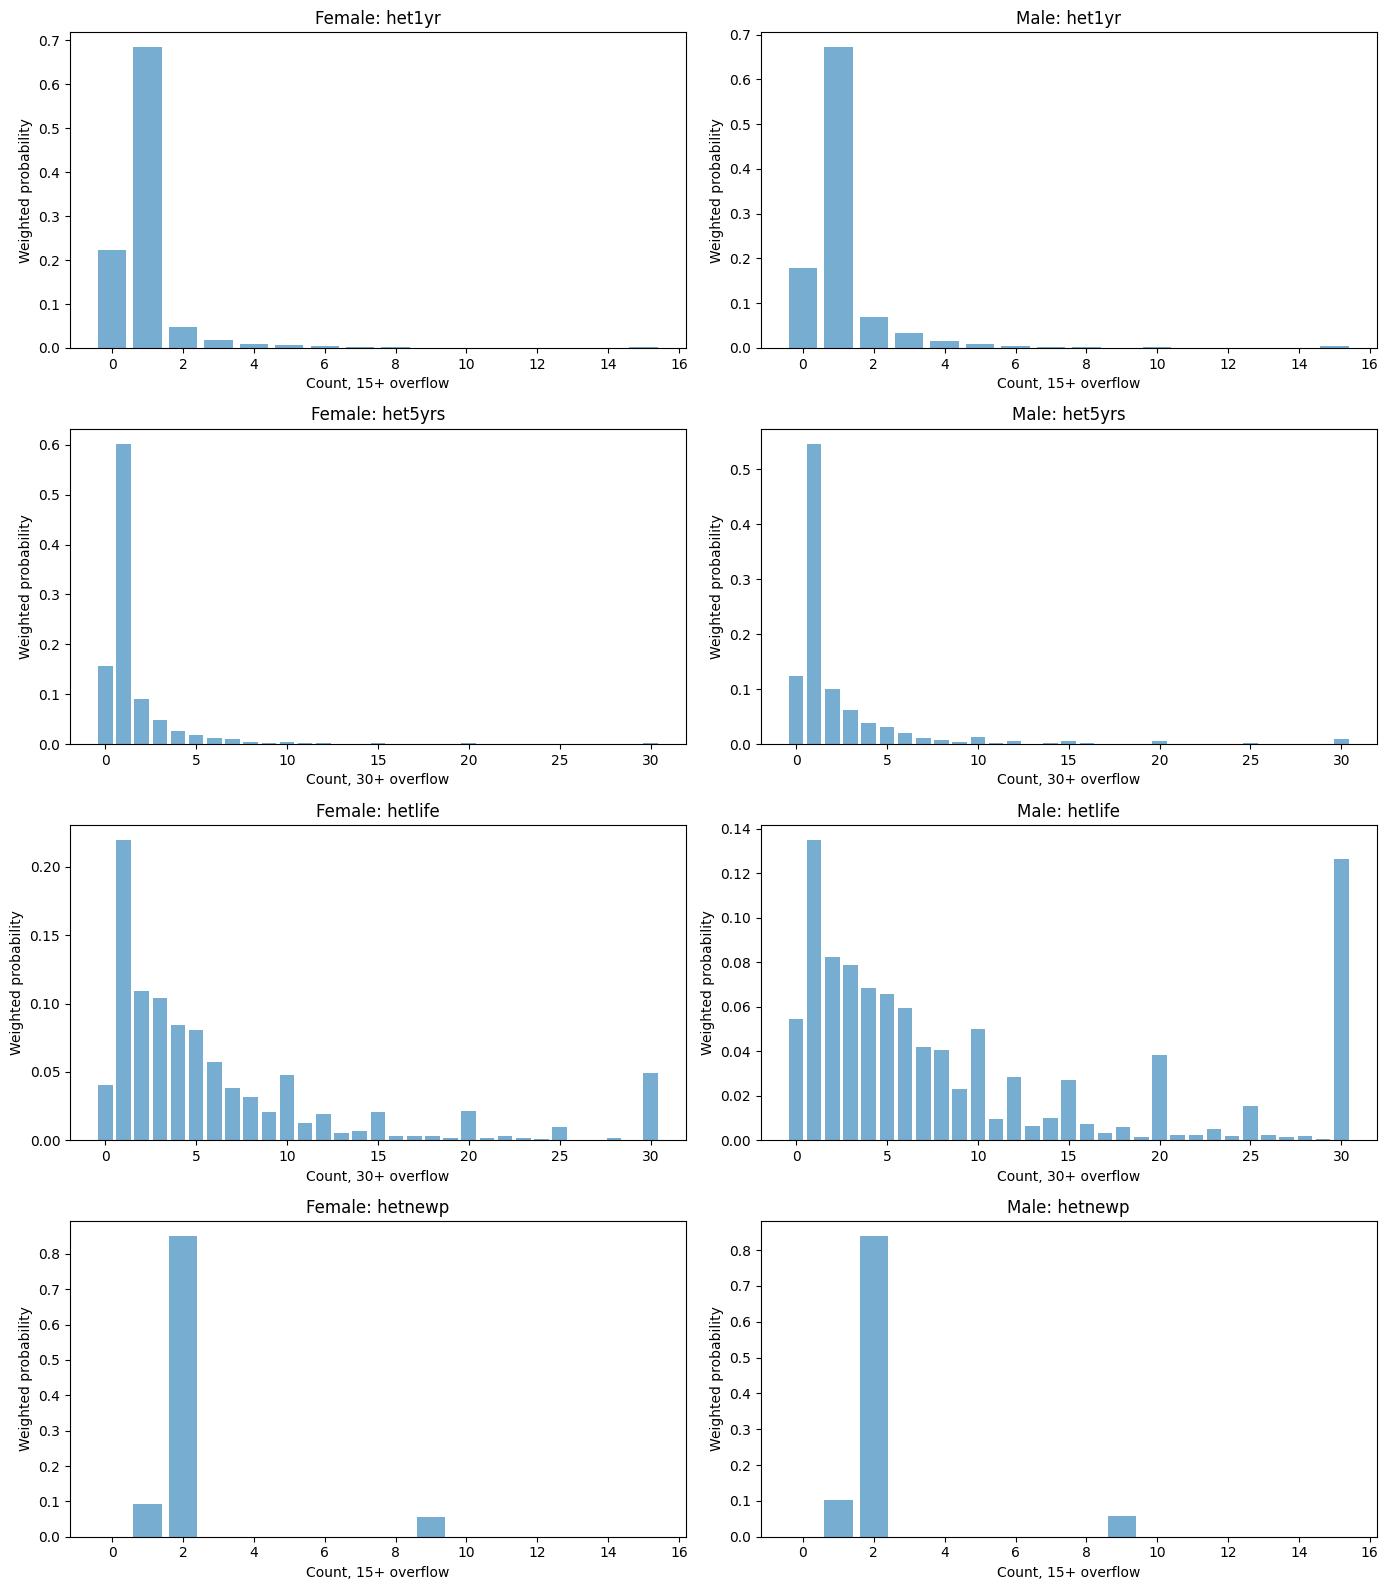

In [14]:
# -----------------------------
# Optional: compare annual, 5-year, and lifetime partner-count distributions
# -----------------------------

fig, axes = plt.subplots(len(available_count_cols), 2, figsize=(14, 4 * len(available_count_cols)), sharey=False)
if len(available_count_cols) == 1:
    axes = np.array([axes])

for row_i, (nice_name, raw_col) in enumerate(available_count_cols.items()):
    col = f'{raw_col}_clean'
    # Keep plots readable; annual counts use a smaller x-axis than lifetime counts.
    max_plot = 15 if 'annual' in nice_name or 'new_partners' in nice_name else 30
    for col_i, sex in enumerate(['Female', 'Male']):
        ax = axes[row_i, col_i]
        g = het_degree[(het_degree['sex_label'] == sex) & het_degree[col].notna()]
        pmf = weighted_pmf(g[col], g['weight'], max_degree=max_plot)
        ax.bar(np.arange(max_plot + 1), pmf.values, alpha=0.6)
        ax.set_title(f'{sex}: {raw_col}')
        ax.set_xlabel(f'Count, {max_plot}+ overflow')
        ax.set_ylabel('Weighted probability')

plt.tight_layout()
plt.show()


## Distribution of active/concurrent heterosexual partners at a point in time

The simple Natsal concurrency variables such as `mrpconcly`, `mrpconcl5y`, `lypartn2`, and `overlp5y` are mainly **binary** indicators: they tell us whether a respondent had any overlapping partnerships, but not the full number of partners active at a given time. To get something closer to a network degree at a point in time, this section reconstructs month-level partnership intervals from the detailed most-recent-partner history.

Interpretation:
- `active_het_partners` = number of heterosexual partners whose interval covers a given month.
- `additional_concurrent_partners` = `max(active_het_partners - 1, 0)`. This is often the most natural "number of concurrent partners" variable: 0 means no concurrency at that point; 1 means two active partners; 2 means three active partners, etc.
- The point-prevalence distribution below is over respondent-months in the last year, weighted by `total_wt`.
- The per-person distribution below is the maximum concurrent count reached by each respondent during the last year.

Important limitation: this is a **lower-bound reconstruction** because Natsal gives detailed dates for the most recent partnerships only. People with more partners than are captured in the detailed partnership-history module may have additional concurrent partners whose timing is unknown. The code reports how many respondents are potentially affected by this truncation.


In [16]:
# -----------------------------
# Reconstruct month-level heterosexual partnership intervals
# using archived month-before-interview variables
# -----------------------------

import numpy as np
import pandas as pd

df.columns = df.columns.str.lower()

sex_col = sex_col.lower()
age_col = age_col.lower()
weight_col = weight_col.lower()

print("Checking available partner timing variables...")
print("Columns containing 'r1firstm':", [c for c in df.columns if "r1firstm" in c])
print("Columns containing 'r1sex':", [c for c in df.columns if "r1sex" in c])
print("Columns containing 'dlover':", [c for c in df.columns if "dlover" in c][:20])


# -----------------------------
# Partner variable specifications
# -----------------------------

# In the archived dataset, r1firstm is months before interview to first sex
# with the most recent partner. r1firstm2 and r1firstm3 are the equivalent
# for the 2nd and 3rd most recent partners where available.
#
# For the last sex date, we do not have exact r1datey/r1datem in your file.
# Instead, use the ordering of "most recent partners":
# partner 1: last sex is treated as interview month, i.e. 0 months ago
# partner 2: use dlover1p2 / dlover5p2 to approximate last sex timing
# partner 3: use dlover1p3 / dlover5p3 to approximate last sex timing
#
# This is an approximation, but it works with your archived variables.

partner_specs = [
    {
        "i": 1,
        "sex": "r1sex",
        "first_months_ago": "r1firstm",
        "dlover1": "dlover1p1",
        "dlover5": "dlover5p1",
    },
    {
        "i": 2,
        "sex": "r1sex2",
        "first_months_ago": "r1firstm2",
        "dlover1": "dlover1p2",
        "dlover5": "dlover5p2",
    },
    {
        "i": 3,
        "sex": "r1sex3",
        "first_months_ago": "r1firstm3",
        "dlover1": "dlover1p3",
        "dlover5": "dlover5p3",
    },
    {
        "i": 4,
        "sex": "r1sex4",
        "first_months_ago": "r1firstm4",
        "dlover1": "dlover1p4",
        "dlover5": "dlover5p4",
    },
]

partner_specs = [
    p for p in partner_specs
    if p["sex"] in df.columns and p["first_months_ago"] in df.columns
]

print("Partner slots available for interval reconstruction:", [p["i"] for p in partner_specs])

if not partner_specs:
    raise KeyError(
        "No partner slots found using archived variables. Expected r1sex and r1firstm-type columns."
    )


# -----------------------------
# Helper functions
# -----------------------------

def as_number(x):
    try:
        if pd.isna(x):
            return np.nan
        return float(x)
    except Exception:
        return np.nan


def clean_months_ago(x):
    """
    r1firstm values:
    valid values are non-negative month counts.
    -1 = not applicable
    -2 = date after interview date
    9999 = not answered
    """
    x = as_number(x)

    if not np.isfinite(x):
        return np.nan

    if x < 0 or x >= 999:
        return np.nan

    return int(round(x))


def approximate_last_months_ago(row, p):
    """
    Approximate last sex month before interview.

    dlover1p*:
      1 = most recent sex was over 1 year ago
      2 = most recent sex was in the last year

    dlover5p*:
      1 = most recent sex was over 5 years ago
      2 = most recent sex was in the last 5 years

    Since exact last month is absent in your archive extract:
      - partner 1 is treated as month 0
      - in last year is approximated as 6 months ago
      - in last 5 years but over 1 year is approximated as 36 months ago
      - over 5 years is excluded for a last-year reconstruction
    """
    if p["i"] == 1:
        return 0

    dlover1 = as_number(row.get(p["dlover1"], np.nan))
    dlover5 = as_number(row.get(p["dlover5"], np.nan))

    if dlover1 == 2:
        return 6

    if dlover1 == 1 and dlover5 == 2:
        return 36

    if dlover5 == 1:
        return np.nan

    return np.nan


def is_heterosexual_partner(row, p):
    respondent_sex = as_number(row.get(sex_col, np.nan))
    partner_sex = as_number(row.get(p["sex"], np.nan))

    return (
        respondent_sex in (1, 2)
        and partner_sex in (1, 2)
        and respondent_sex != partner_sex
    )


def row_to_heterosexual_intervals(row, partner_specs):
    """
    Return intervals as months-before-interview.

    Month 0 = interview month.
    Month 1 = one month before interview.
    Month 11 = eleven months before interview.

    A partnership is active in month m if:
        first_months_ago >= m >= last_months_ago

    Example:
      first_months_ago = 20, last_months_ago = 0 means active from
      20 months ago through the interview month.
    """
    intervals = []

    for p in partner_specs:
        if not is_heterosexual_partner(row, p):
            continue

        first_ago = clean_months_ago(row.get(p["first_months_ago"], np.nan))
        last_ago = approximate_last_months_ago(row, p)

        if not np.isfinite(first_ago) or not np.isfinite(last_ago):
            continue

        first_ago = int(first_ago)
        last_ago = int(last_ago)

        # If dates are inconsistent, keep a conservative interval.
        if first_ago < last_ago:
            first_ago, last_ago = last_ago, first_ago

        intervals.append(
            {
                "partner_slot": p["i"],
                "first_months_ago": first_ago,
                "last_months_ago": last_ago,
            }
        )

    return intervals


# -----------------------------
# Main reconstruction function
# -----------------------------

def interval_count_distribution(data, window_months=12):
    """
    Return respondent-month records and respondent-level maxima.

    This version works with archived variables such as r1firstm.
    It is approximate because your loaded dataset does not contain exact
    r1datey/r1datem last-sex month variables.
    """

    point_rows = []
    person_rows = []

    base_cols = [sex_col, age_col, weight_col]

    partner_cols = sorted(
        {
            v
            for p in partner_specs
            for v in p.values()
            if isinstance(v, str) and v in data.columns
        }
    )

    cols = [c for c in base_cols + partner_cols if c in data.columns]

    missing_core_cols = [
        c for c in [sex_col, age_col, weight_col]
        if c not in cols
    ]

    if missing_core_cols:
        raise KeyError(f"Missing core columns needed for reconstruction: {missing_core_cols}")

    for idx, row in data[cols].iterrows():
        respondent_sex = as_number(row.get(sex_col, np.nan))

        if respondent_sex not in (1, 2):
            continue

        age = as_number(row.get(age_col, np.nan))

        if not np.isfinite(age) or age < 16 or age > 74:
            continue

        intervals = row_to_heterosexual_intervals(row, partner_specs)

        active_counts = []

        for month_ago in range(0, window_months):
            active = sum(
                iv["first_months_ago"] >= month_ago >= iv["last_months_ago"]
                for iv in intervals
            )

            active_counts.append(active)

            point_rows.append(
                {
                    "respondent_index": idx,
                    "rsex": int(respondent_sex),
                    "sex_label": {1: "Male", 2: "Female"}.get(int(respondent_sex)),
                    "age": age,
                    "weight": as_number(row.get(weight_col, np.nan)),
                    "month_before_interview": month_ago,
                    "active_het_partners": int(active),
                    "additional_concurrent_partners": int(max(active - 1, 0)),
                }
            )

        max_active = int(np.max(active_counts)) if len(active_counts) else 0

        person_rows.append(
            {
                "respondent_index": idx,
                "rsex": int(respondent_sex),
                "sex_label": {1: "Male", 2: "Female"}.get(int(respondent_sex)),
                "age": age,
                "weight": as_number(row.get(weight_col, np.nan)),
                "n_timed_het_partner_intervals": len(intervals),
                "max_active_het_partners": max_active,
                "max_additional_concurrent_partners": int(max(max_active - 1, 0)),
            }
        )

    return pd.DataFrame(point_rows), pd.DataFrame(person_rows)


# -----------------------------
# Run last-year reconstruction
# -----------------------------

point_counts_ly, person_max_ly = interval_count_distribution(
    df,
    window_months=12,
)

print("Respondent-month rows in last-year reconstruction:", len(point_counts_ly))

if len(person_max_ly):
    print(
        "Respondents in last-year reconstruction:",
        person_max_ly["respondent_index"].nunique(),
    )

    print("\nDistribution of maximum active heterosexual partners in the last year:")
    print(person_max_ly["max_active_het_partners"].value_counts().sort_index())

else:
    print("Respondents in last-year reconstruction: 0")

person_max_ly.head()

Checking available partner timing variables...
Columns containing 'r1firstm': ['r1firstm', 'r1firstm2', 'r1firstm3', 'r1firstm4']
Columns containing 'r1sex': ['r1sex', 'r1sexagn', 'r1sex2', 'r1sexagn2', 'r1sex3', 'r1sexagn3', 'r1sex4', 'r1sexagn4']
Columns containing 'dlover': ['dlover1p1', 'dlover1p2', 'dlover1p3', 'dlover1p4', 'dlover5p1', 'dlover5p2', 'dlover5p3', 'dlover5p4']
Partner slots available for interval reconstruction: [1, 2, 3, 4]
Respondent-month rows in last-year reconstruction: 181944
Respondents in last-year reconstruction: 15162

Distribution of maximum active heterosexual partners in the last year:
max_active_het_partners
0     2707
1    11468
2      856
3      131
Name: count, dtype: int64


,respondent_index,rsex,sex_label,age,weight,n_timed_het_partner_intervals,max_active_het_partners,max_additional_concurrent_partners
0,0,1,Male,25.0,0.460514,0,0,0
1,1,2,Female,30.0,1.788954,1,1,0
2,2,1,Male,29.0,1.381543,2,1,0
3,3,2,Female,27.0,0.739011,2,1,0
4,4,2,Female,41.0,1.923944,1,1,0


In [17]:

# -----------------------------
# Diagnostics: how much truncation might affect the concurrent-partner count?
# -----------------------------

# If het1yr is available, compare the reported number of heterosexual partners in the last year with
# the number of timed heterosexual partner intervals reconstructed from the detailed partnership history.
if 'het1yr' in df.columns and len(person_max_ly):
    tmp = person_max_ly.merge(
        df[['het1yr']].rename_axis('respondent_index').reset_index(),
        on='respondent_index',
        how='left'
    )
    tmp['het1yr_clean'] = clean_count(tmp['het1yr'], max_reasonable=365)
    tmp['possible_timing_truncation'] = (
        tmp['het1yr_clean'].notna()
        & (tmp['het1yr_clean'] > tmp['n_timed_het_partner_intervals'])
    )

    trunc_diag = []
    for sex, g in tmp.groupby('sex_label'):
        trunc_diag.append({
            'sex_label': sex,
            'weighted_prop_with_more_reported_het1yr_partners_than_timed_intervals': weighted_mean(
                g['possible_timing_truncation'].astype(float), g['weight']
            ),
            'weighted_mean_reported_het1yr': weighted_mean(g['het1yr_clean'], g['weight']),
            'weighted_mean_timed_intervals': weighted_mean(g['n_timed_het_partner_intervals'], g['weight']),
            'n_unweighted': len(g),
        })
    trunc_diag = pd.DataFrame(trunc_diag)
    display(trunc_diag)
else:
    print('het1yr was not found, so truncation against annual partner count could not be checked.')


,sex_label,weighted_prop_with_more_reported_het1yr_partners_than_timed_intervals,weighted_mean_reported_het1yr,weighted_mean_timed_intervals,n_unweighted
0,Female,0.082017,1.042088,1.079092,8869
1,Male,0.120458,1.272877,1.112946,6293



Female: P(active heterosexual partners = k) at a random month
degree_plot
0     0.174942
1     0.810196
2     0.013790
3     0.001072
4     0.000000
5     0.000000
6     0.000000
7+    0.000000
Name: weight, dtype: float64

Female: P(additional concurrent partners = k) at a random month
degree_plot
0     0.985138
1     0.013790
2     0.001072
3     0.000000
4     0.000000
5     0.000000
6+    0.000000
Name: weight, dtype: float64


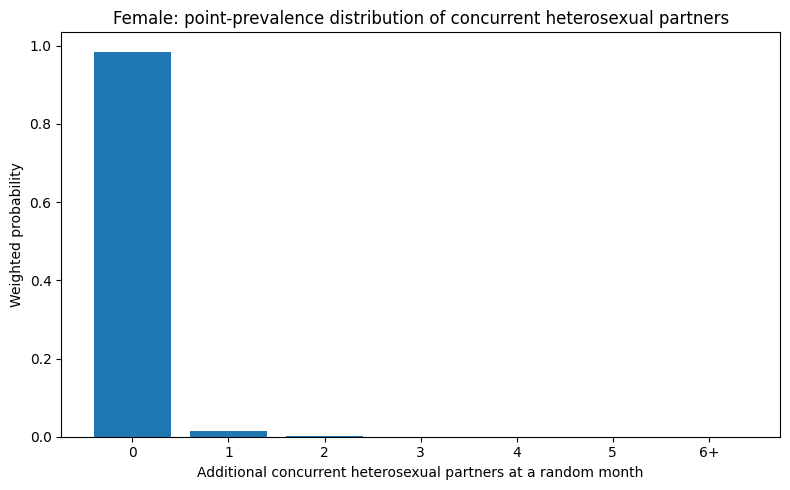


Male: P(active heterosexual partners = k) at a random month
degree_plot
0     0.213628
1     0.763777
2     0.020470
3     0.002125
4     0.000000
5     0.000000
6     0.000000
7+    0.000000
Name: weight, dtype: float64

Male: P(additional concurrent partners = k) at a random month
degree_plot
0     0.977405
1     0.020470
2     0.002125
3     0.000000
4     0.000000
5     0.000000
6+    0.000000
Name: weight, dtype: float64


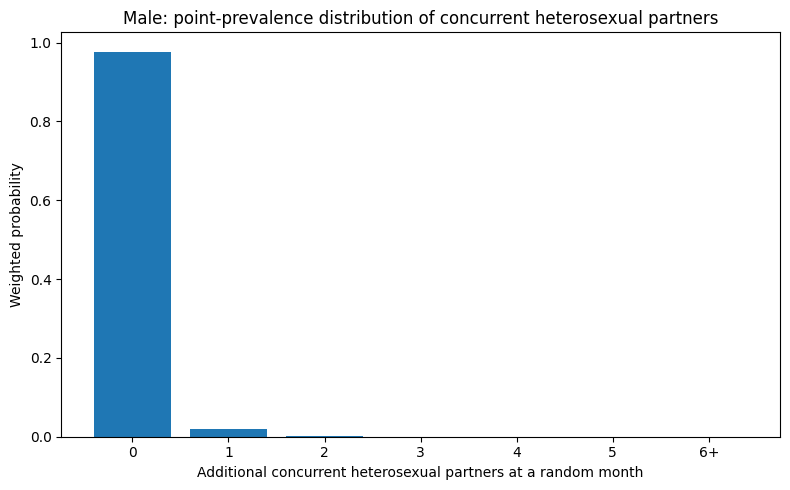

In [18]:

# -----------------------------
# Point-prevalence distribution: active/concurrent heterosexual partners at a random month
# -----------------------------

max_concurrent_bin = 6  # final bin is max_concurrent_bin+

concurrent_pmf_by_sex = {}
active_pmf_by_sex = {}

for sex in ['Female', 'Male']:
    g = point_counts_ly[(point_counts_ly['sex_label'] == sex) & point_counts_ly['weight'].notna()]
    if len(g) == 0:
        continue

    active_pmf = weighted_pmf(g['active_het_partners'], g['weight'], max_degree=max_concurrent_bin + 1)
    concurrent_pmf = weighted_pmf(g['additional_concurrent_partners'], g['weight'], max_degree=max_concurrent_bin)

    active_pmf_by_sex[sex] = active_pmf
    concurrent_pmf_by_sex[sex] = concurrent_pmf

    print(f'\n{sex}: P(active heterosexual partners = k) at a random month')
    print(active_pmf.rename(index={max_concurrent_bin + 1: f'{max_concurrent_bin + 1}+'}))

    print(f'\n{sex}: P(additional concurrent partners = k) at a random month')
    print(concurrent_pmf.rename(index={max_concurrent_bin: f'{max_concurrent_bin}+'}))

    fig, ax = plt.subplots(figsize=(8, 5))
    labels = [str(i) for i in range(max_concurrent_bin)] + [f'{max_concurrent_bin}+']
    ax.bar(labels, concurrent_pmf.values)
    ax.set_xlabel('Additional concurrent heterosexual partners at a random month')
    ax.set_ylabel('Weighted probability')
    ax.set_title(f'{sex}: point-prevalence distribution of concurrent heterosexual partners')
    plt.tight_layout()
    plt.show()



Female: P(max additional concurrent partners in last year = k)
degree_plot
0     0.957770
1     0.037429
2     0.004801
3     0.000000
4     0.000000
5     0.000000
6+    0.000000
Name: weight, dtype: float64


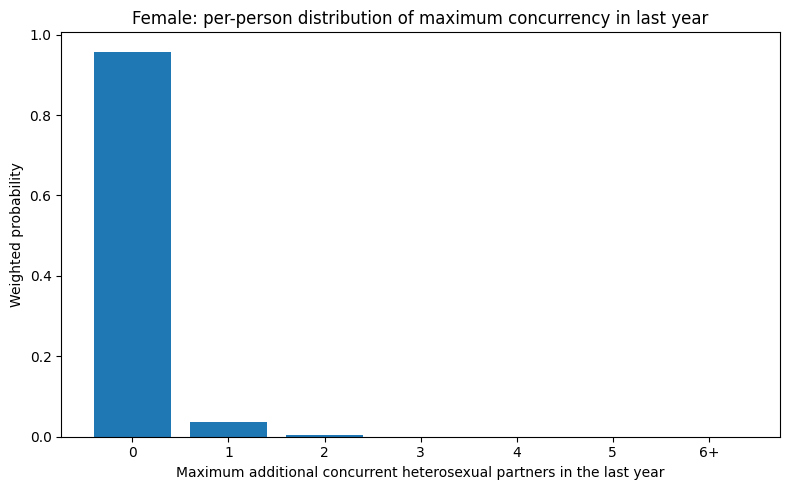


Male: P(max additional concurrent partners in last year = k)
degree_plot
0     0.943295
1     0.048694
2     0.008011
3     0.000000
4     0.000000
5     0.000000
6+    0.000000
Name: weight, dtype: float64


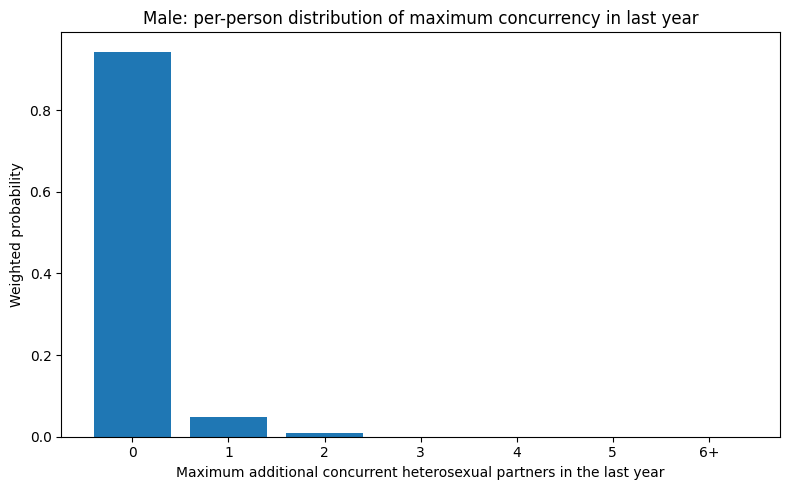

In [19]:

# -----------------------------
# Per-person distribution: maximum concurrent heterosexual partners reached in the last year
# -----------------------------

max_person_bin = 6  # final bin is max_person_bin+
max_concurrent_pmf_by_sex = {}

for sex in ['Female', 'Male']:
    g = person_max_ly[(person_max_ly['sex_label'] == sex) & person_max_ly['weight'].notna()]
    if len(g) == 0:
        continue

    pmf = weighted_pmf(g['max_additional_concurrent_partners'], g['weight'], max_degree=max_person_bin)
    max_concurrent_pmf_by_sex[sex] = pmf

    print(f'\n{sex}: P(max additional concurrent partners in last year = k)')
    print(pmf.rename(index={max_person_bin: f'{max_person_bin}+'}))

    fig, ax = plt.subplots(figsize=(8, 5))
    labels = [str(i) for i in range(max_person_bin)] + [f'{max_person_bin}+']
    ax.bar(labels, pmf.values)
    ax.set_xlabel('Maximum additional concurrent heterosexual partners in the last year')
    ax.set_ylabel('Weighted probability')
    ax.set_title(f'{sex}: per-person distribution of maximum concurrency in last year')
    plt.tight_layout()
    plt.show()

# These dictionaries are useful for simulation input:
# - concurrent_pmf_by_sex: point-prevalence distribution of additional concurrent partners
# - active_pmf_by_sex: point-prevalence distribution of active heterosexual partners
# - max_concurrent_pmf_by_sex: per-person maximum additional concurrent partners over the last year


## Duration of heterosexual relations: casual versus serious/married

This section estimates the distribution of **heterosexual relationship duration** from the detailed most-recent-partner variables.

Codebook logic used here:

- `r1rel`, `r1rel2`, `r1rel3`, `r1rel4`: relationship status at most recent sex with partner 1, 2, 3, or 4.
  - `1` = living together / married / civil partnership
  - `2` = steady relationship
  - `3` = used to be in a steady relationship, but not at the time
  - `4` = known each other for a while, but not in a steady relationship
  - `5` = recently met
  - `6` = just met for the first time
- `r1recm`, `r1recm2`, `r1recm3`, `r1recm4`: number of months before interview of most recent sex with that partner.
- `r1firstm`, `r1firstm2`, `r1firstm3`, `r1firstm4`: number of months before interview of first sex with that partner.
- `r1mtha*` / `r1mthb*`: extra short-duration categories for very recent partnerships, distinguishing less than 7 days, 7 days to 2 weeks, 2 to 4 weeks, and over 4 weeks.
- `r1sex*` and `rsex`: used to filter to heterosexual/opposite-sex partnerships.

For the main analysis below I classify:

- **Serious/married**: `r1rel*` in `{1, 2}` = living together/married/civil partnership or steady relationship.
- **Casual**: `r1rel*` in `{4, 5, 6}` = known but not steady, recently met, or just met.
- Code `3` is treated as `former_steady` and excluded from the two main fitted distributions by default, because it is neither clearly casual nor currently serious. You can switch `include_former_steady_with_casual = True` below if you prefer to fold this group into casual partnerships.

The duration variable is reconstructed as:

```python
duration_months_calendar = r1firstm - r1recm + 1
```

because larger month offsets mean further back in time. The `+1` treats a partnership whose first and most recent sex occurred in the same calendar month as a one-month interval. A refined version, `duration_months_refined`, uses `r1mtha*` / `r1mthb*` to give sub-month durations when available.

Caveat: this is a **reported sexual relationship duration**, not necessarily romantic relationship duration. It is also based on detailed recent-partner histories, so it is best interpreted as a distribution of durations among observed/reportable partnerships rather than all partnerships in the population.

In [8]:
# -----------------------------
# Build heterosexual relationship-duration dataset
# -----------------------------

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from IPython.display import display

# Toggle this if you want to treat "used to be in a steady relationship, but not at time"
# as casual rather than excluding it from the two main groups.
include_former_steady_with_casual = False

# Prefer survey weights if available; otherwise use equal weights.
weight_col = 'total_wt' if 'total_wt' in df.columns else None
sex_col = 'rsex'

REL_LABELS = {
    1: 'living together / married / civil partnership',
    2: 'steady relationship',
    3: 'used to be steady, not at time',
    4: 'known for a while, not steady',
    5: 'recently met',
    6: 'just met for first time',
}

SHORT_DURATION_DAYS = {
    1: 3.5,    # less than 7 days
    2: 10.5,   # 7 days to 2 weeks
    3: 21.0,   # 2 to 4 weeks
    4: 35.0,   # over 4 weeks, conservative midpoint for plotting/fitting
}

partner_specs = [
    {'partner_n': 1, 'sex': 'r1sex',  'rel': 'r1rel',  'first_once': 'r1first',  'recent_m': 'r1recm',  'first_m': 'r1firstm',  'short_a': 'r1mtha',  'short_b': 'r1mthb'},
    {'partner_n': 2, 'sex': 'r1sex2', 'rel': 'r1rel2', 'first_once': 'r1first2', 'recent_m': 'r1recm2', 'first_m': 'r1firstm2', 'short_a': 'r1mtha2', 'short_b': 'r1mthb2'},
    {'partner_n': 3, 'sex': 'r1sex3', 'rel': 'r1rel3', 'first_once': 'r1first3', 'recent_m': 'r1recm3', 'first_m': 'r1firstm3', 'short_a': 'r1mtha3', 'short_b': 'r1mthb3'},
    {'partner_n': 4, 'sex': 'r1sex4', 'rel': 'r1rel4', 'first_once': 'r1first4', 'recent_m': 'r1recm4', 'first_m': 'r1firstm4', 'short_a': 'r1mtha4', 'short_b': 'r1mthb4'},
]

def has_columns(cols):
    return all(c in df.columns for c in cols)

def clean_numeric(s):
    return pd.to_numeric(s, errors='coerce')

def valid_month_offset(x):
    # r1recm/r1firstm use -1/-2 and 9999 as invalid/special values.
    return pd.notna(x) and (0 <= x < 9999)

def valid_code(x, allowed):
    return pd.notna(x) and int(x) in allowed

def relation_group(rel_code):
    if pd.isna(rel_code):
        return np.nan
    rel_code = int(rel_code)
    if rel_code in (1, 2):
        return 'serious_married'
    if rel_code == 3:
        return 'casual' if include_former_steady_with_casual else 'former_steady'
    if rel_code in (4, 5, 6):
        return 'casual'
    return np.nan

def short_duration_months(row, short_a_col, short_b_col):
    # r1mtha is used for likely continuing partnerships; r1mthb is used for not continuing / unknown.
    vals = []
    for col in [short_a_col, short_b_col]:
        if col in row.index and valid_code(row[col], SHORT_DURATION_DAYS.keys()):
            vals.append(SHORT_DURATION_DAYS[int(row[col])] / 30.4375)
    if len(vals) == 0:
        return np.nan
    # If both somehow exist, take the smaller value; they are alternative routes in the questionnaire.
    return min(vals)

rows = []
for spec in partner_specs:
    needed = [sex_col, spec['sex'], spec['rel'], spec['recent_m'], spec['first_m']]
    optional = [spec['first_once'], spec['short_a'], spec['short_b']]
    available_optional = [c for c in optional if c in df.columns]
    if not has_columns(needed):
        print(f"Skipping partner {spec['partner_n']}: missing at least one of {needed}")
        continue

    cols = needed + available_optional + ([weight_col] if weight_col else [])
    tmp = df[cols].copy()
    tmp['partner_n'] = spec['partner_n']

    tmp[sex_col] = clean_numeric(tmp[sex_col])
    tmp[spec['sex']] = clean_numeric(tmp[spec['sex']])
    tmp[spec['rel']] = clean_numeric(tmp[spec['rel']])
    tmp[spec['recent_m']] = clean_numeric(tmp[spec['recent_m']])
    tmp[spec['first_m']] = clean_numeric(tmp[spec['first_m']])
    for col in available_optional:
        tmp[col] = clean_numeric(tmp[col])

    # Heterosexual/opposite-sex partnerships only.
    tmp = tmp[((tmp[sex_col] == 1) & (tmp[spec['sex']] == 2)) | ((tmp[sex_col] == 2) & (tmp[spec['sex']] == 1))]

    # Valid relationship-status categories.
    tmp = tmp[tmp[spec['rel']].isin([1, 2, 3, 4, 5, 6])]

    for _, row in tmp.iterrows():
        recent_m = row[spec['recent_m']]
        first_m = row[spec['first_m']]
        dur_cal = np.nan
        if valid_month_offset(recent_m) and valid_month_offset(first_m) and first_m >= recent_m:
            dur_cal = first_m - recent_m + 1
        elif spec['first_once'] in row.index and row[spec['first_once']] == 1:
            dur_cal = 1.0

        dur_short = short_duration_months(row, spec['short_a'], spec['short_b'])
        if pd.notna(dur_short) and (pd.isna(dur_cal) or dur_cal <= 1.0):
            dur_refined = dur_short
        else:
            dur_refined = dur_cal

        if pd.notna(dur_refined) and dur_refined > 0:
            rel_code = int(row[spec['rel']])
            rows.append({
                'partner_n': spec['partner_n'],
                'respondent_sex': int(row[sex_col]),
                'partner_sex': int(row[spec['sex']]),
                'relation_code': rel_code,
                'relation_label': REL_LABELS.get(rel_code, 'unknown'),
                'relation_group': relation_group(rel_code),
                'duration_months_calendar': dur_cal,
                'duration_months_refined': dur_refined,
                'short_duration_months': dur_short,
                'weight': float(row[weight_col]) if weight_col else 1.0,
            })

rel_duration_df = pd.DataFrame(rows)

print(f"Constructed {len(rel_duration_df):,} heterosexual partner-duration records from detailed partner variables.")
if len(rel_duration_df):
    display(rel_duration_df.head())
    display(pd.crosstab(rel_duration_df['relation_group'], rel_duration_df['relation_label'], dropna=False))
else:
    print("No valid duration records found. Check that the detailed partner variables are in df and have expected names.")


Constructed 21,519 heterosexual partner-duration records from detailed partner variables.


,partner_n,respondent_sex,partner_sex,relation_code,relation_label,relation_group,duration_months_calendar,duration_months_refined,short_duration_months,weight
0,1,1,2,4,"known for a while, not steady",casual,1.0,1.0,NaN,0.460514
1,1,2,1,1,living together / married / civil partnership,serious_married,27.0,27.0,NaN,1.788954
2,1,1,2,1,living together / married / civil partnership,serious_married,14.0,14.0,NaN,1.381543
3,1,2,1,2,steady relationship,serious_married,11.0,11.0,NaN,0.739011
4,1,2,1,1,living together / married / civil partnership,serious_married,233.0,233.0,NaN,1.923944


relation_label,just met for first time,"known for a while, not steady",living together / married / civil partnership,recently met,steady relationship,"used to be steady, not at time"
relation_group,,,,,,
casual,814,3906,0,1854,0,0
former_steady,0,0,0,0,0,1354
serious_married,0,0,8377,0,5214,0


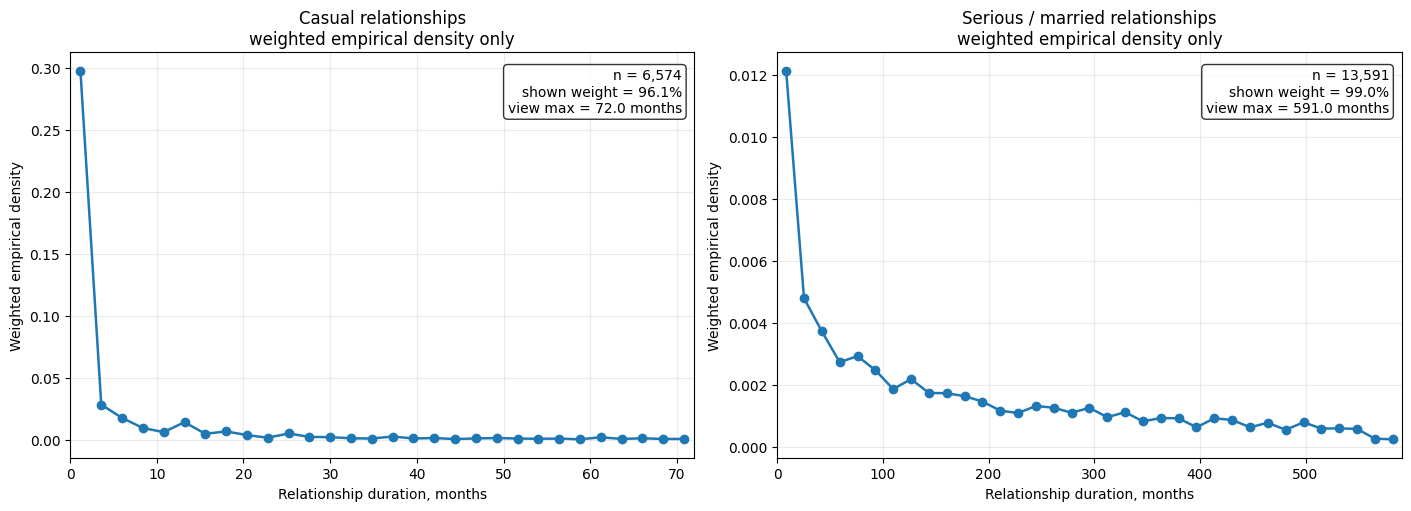

,group,n_records,weighted_median_months,weighted_p75_months,weighted_p90_months,weighted_p99_months,plot_max_months,plotted_weight_fraction
0,casual,6574,1.0,4.0,24.0,237.810558,72.0,0.961042
1,serious_married,13591,112.0,277.0,433.0,591.000000,591.0,0.990100


In [12]:
CASUAL_CODES_FOR_FIT = [4, 5, 6]
SERIOUS_CODES_FOR_FIT = [1]      # change to [1, 2] if you want all steady relationships included
FORMER_STEADY_CODES = [3]
DURATION_COL = 'duration_months_refined'
WEIGHT_COL = 'weight'

DURATION_COL = 'duration_months_refined'
GROUP_ORDER = ['casual', 'serious_married']
GROUP_TITLES = {
    'casual': 'Casual relationships',
    'serious_married': 'Serious / married relationships',
}


def _clean_duration_group(data, group, duration_col=DURATION_COL):
    g = data[data['relation_group'] == group].copy()
    if len(g) == 0:
        return np.array([]), np.array([])
    x = pd.to_numeric(g[duration_col], errors='coerce').to_numpy(dtype=float)
    w = pd.to_numeric(g['weight'], errors='coerce').to_numpy(dtype=float)
    ok = np.isfinite(x) & (x > 0) & np.isfinite(w) & (w > 0)
    return x[ok], w[ok]


def _weighted_quantile(x, q, w=None):
    x = np.asarray(x, dtype=float)
    if w is None:
        w = np.ones_like(x, dtype=float)
    else:
        w = np.asarray(w, dtype=float)
    ok = np.isfinite(x) & np.isfinite(w) & (w > 0)
    x, w = x[ok], w[ok]
    if len(x) == 0:
        return np.nan
    order = np.argsort(x)
    x, w = x[order], w[order]
    cw = np.cumsum(w) / np.sum(w)
    return float(np.interp(q, cw, x))


def _empirical_density_line(x, w, max_months, n_bins=30):
    # Linear bins, not log bins. This is deliberately better for the casual relationships.
    # Values above max_months are omitted from the plotted line only, not from later fitting.
    keep = x <= max_months
    x_plot, w_plot = x[keep], w[keep]
    if len(x_plot) == 0:
        return np.array([]), np.array([]), 0.0

    bins = np.linspace(0, max_months, n_bins + 1)
    counts, edges = np.histogram(x_plot, bins=bins, weights=w_plot)
    widths = np.diff(edges)
    centers = edges[:-1] + widths / 2

    # Density integrates to 1 over the displayed range. This makes the line comparable
    # across casual and serious/married groups even when their durations have different scales.
    density = counts / (np.sum(counts) * widths)
    displayed_weight_fraction = float(np.sum(w_plot) / np.sum(w))
    return centers, density, displayed_weight_fraction


if 'rel_duration_df' not in globals():
    raise NameError("rel_duration_df was not found. Run the duration data-building cell before this one.")

empirical_duration_summary = []
fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)

for ax, group in zip(axes, GROUP_ORDER):
    x, w = _clean_duration_group(rel_duration_df, group)
    if len(x) == 0:
        ax.set_title(f'{GROUP_TITLES[group]}: no valid records')
        ax.axis('off')
        continue

    # Use a high-percentile view rather than allowing a tiny number of very long durations
    # to flatten the main empirical pattern. The fitting cell below still uses all valid data.
    if group == 'casual':
        max_months = min(max(_weighted_quantile(x, 0.99, w), 12), 72)
        n_bins = 30
    else:
        max_months = min(max(_weighted_quantile(x, 0.99, w), 60), 600)
        n_bins = 35

    centers, density, shown = _empirical_density_line(x, w, max_months=max_months, n_bins=n_bins)
    ax.plot(centers, density, marker='o', linewidth=1.8)
    ax.set_title(f'{GROUP_TITLES[group]}\nweighted empirical density only')
    ax.set_xlabel('Relationship duration, months')
    ax.set_ylabel('Weighted empirical density')
    ax.set_xlim(0, max_months)
    ax.grid(True, alpha=0.25)
    ax.text(
        0.98, 0.96,
        f'n = {len(x):,}\nshown weight = {shown:.1%}\nview max = {max_months:.1f} months',
        ha='right', va='top', transform=ax.transAxes,
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8),
    )

    empirical_duration_summary.append({
        'group': group,
        'n_records': len(x),
        'weighted_median_months': _weighted_quantile(x, 0.50, w),
        'weighted_p75_months': _weighted_quantile(x, 0.75, w),
        'weighted_p90_months': _weighted_quantile(x, 0.90, w),
        'weighted_p99_months': _weighted_quantile(x, 0.99, w),
        'plot_max_months': max_months,
        'plotted_weight_fraction': shown,
    })

plt.show()

display(pd.DataFrame(empirical_duration_summary))


c:\Users\richa\miniconda3\envs\summerhpvsim\lib\site-packages\scipy\stats\_continuous_distns.py:1319: RuntimeWarning: overflow encountered in power
  return np.log(c) + np.log(d) + sc.xlogy(c - 1, x) + sc.xlog1py(-d-1, x**c)



Casual relationships — fitted distributions ranked by AIC
Duration variable used: duration_months_calendar


,distribution_name,distribution_parameters_values,AIC
0,two_component_lognormal_mixture,"c1: pi=0.631, median=1, sigma_log=0.0001; c2: ...",-40101.29
1,burr12,"109.4, 0.0104445, 0, 0.96321",23911.01
2,invgauss,"6.41652, 0, 1.64066",32959.14
3,exponweib,"416.255, 0.146878, 0, 7.0305e-06",33250.56
4,fisk_loglogistic,"1.4335, 0, 1.75836",34355.74
5,lognorm,"1.36023, 0, 2.31077",34970.52
6,gengamma,"12.4486, 0.189343, 0, 4.52417e-06",35964.37
7,weibull_min,"0.573264, 0, 4.9767",38453.37
8,gamma,"0.42909, 0, 24.534",40844.27
9,expon,"0, 10.5273",46355.38



Serious / married relationships — fitted distributions ranked by AIC
Duration variable used: duration_months_calendar


,distribution_name,distribution_parameters_values,AIC
0,two_component_lognormal_mixture,"c1: pi=0.438, median=14.9, sigma_log=1.73; c2:...",163867.52
1,exponweib,"0.367634, 1.36254, 0, 264.202",164592.79
2,gengamma,"0.350731, 1.43071, 0, 332.716",164662.71
3,gamma,"0.563943, 0, 224.52",165303.04
4,burr12,"0.684568, 1313.32, 0, 3.59039e+06",166010.57
5,weibull_min,"0.683388, 0, 99.8542",166015.78
6,status_lognormal_mixture,"relation_code=1: pi=0.728, median=129, sigma_l...",166536.46
7,expon,"0, 126.616",167517.87
8,lognorm,"1.86841, 0, 41.9032",169489.07
9,fisk_loglogistic,"0.923893, 0, 49.546",169674.89


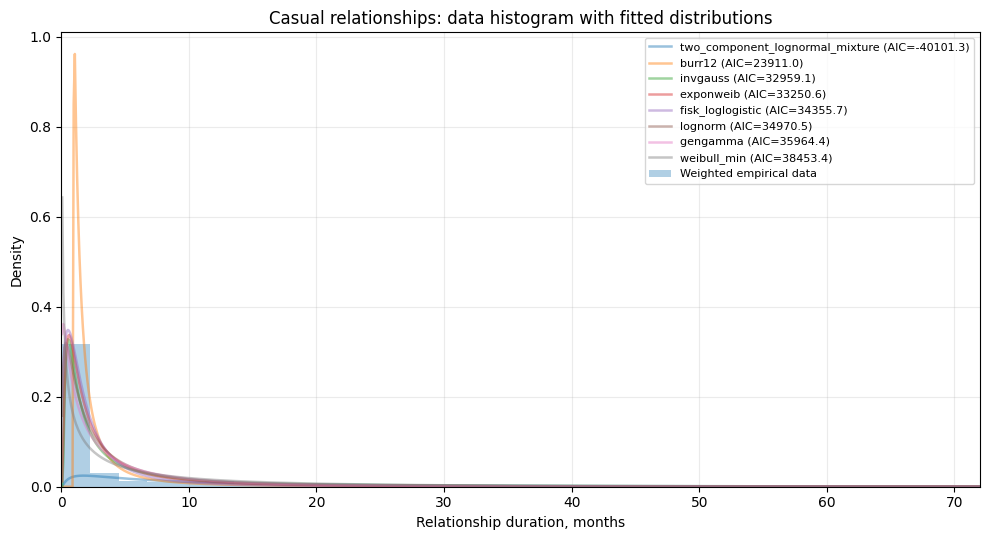

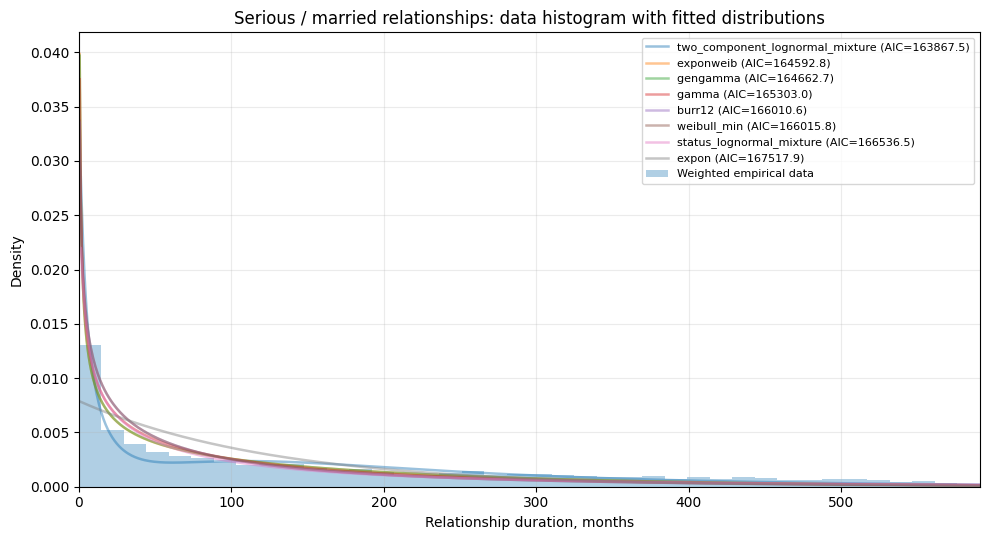

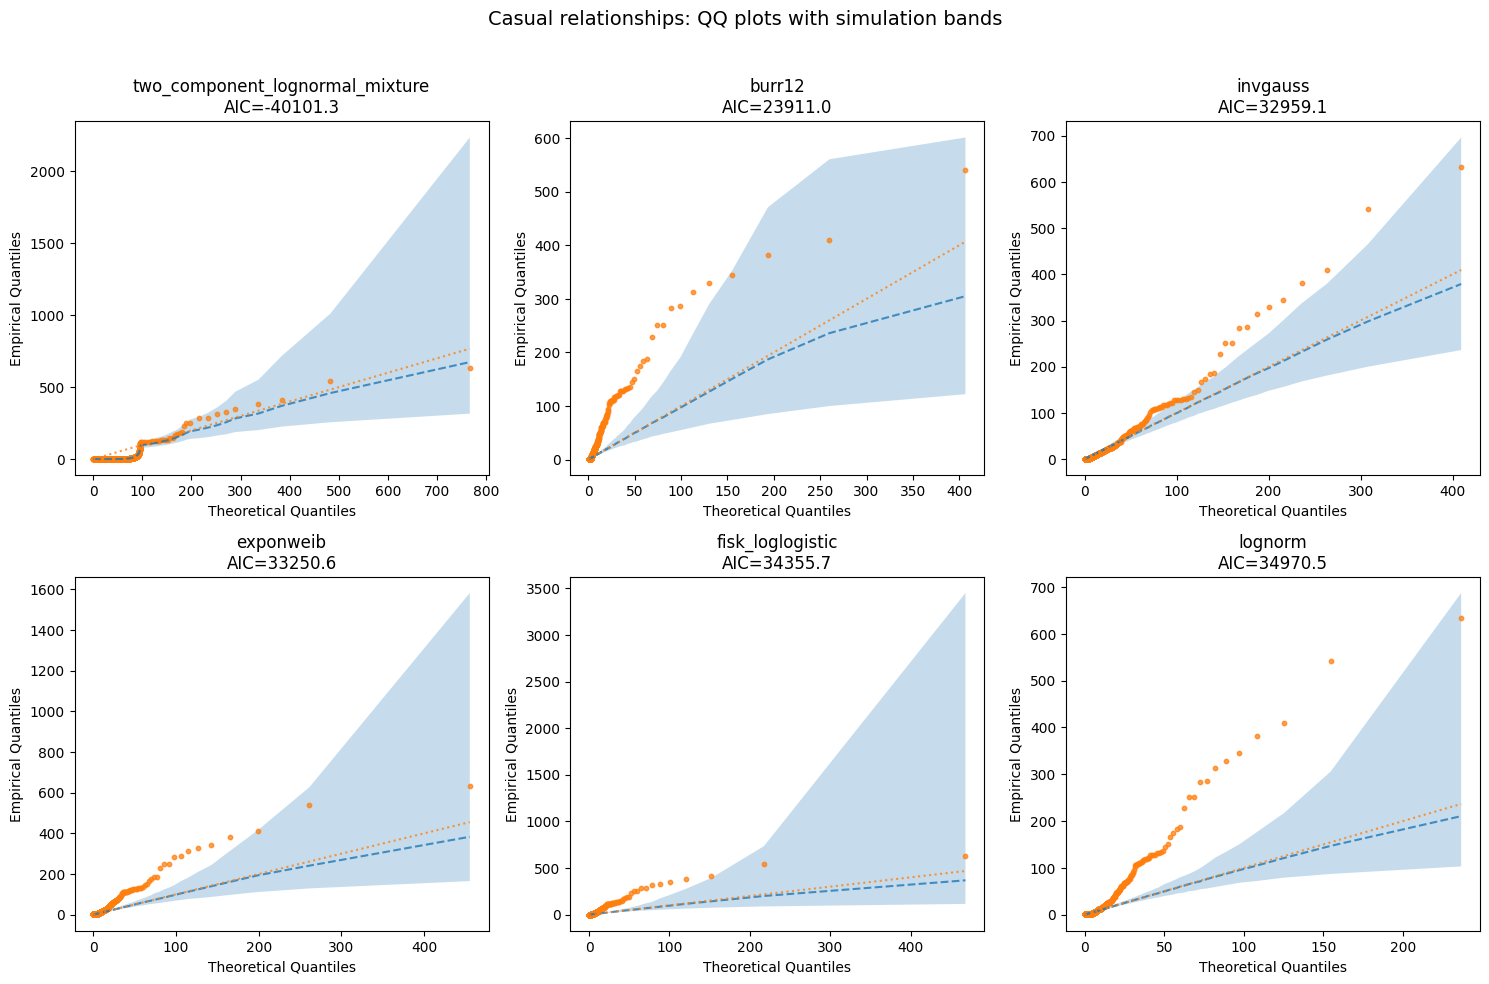

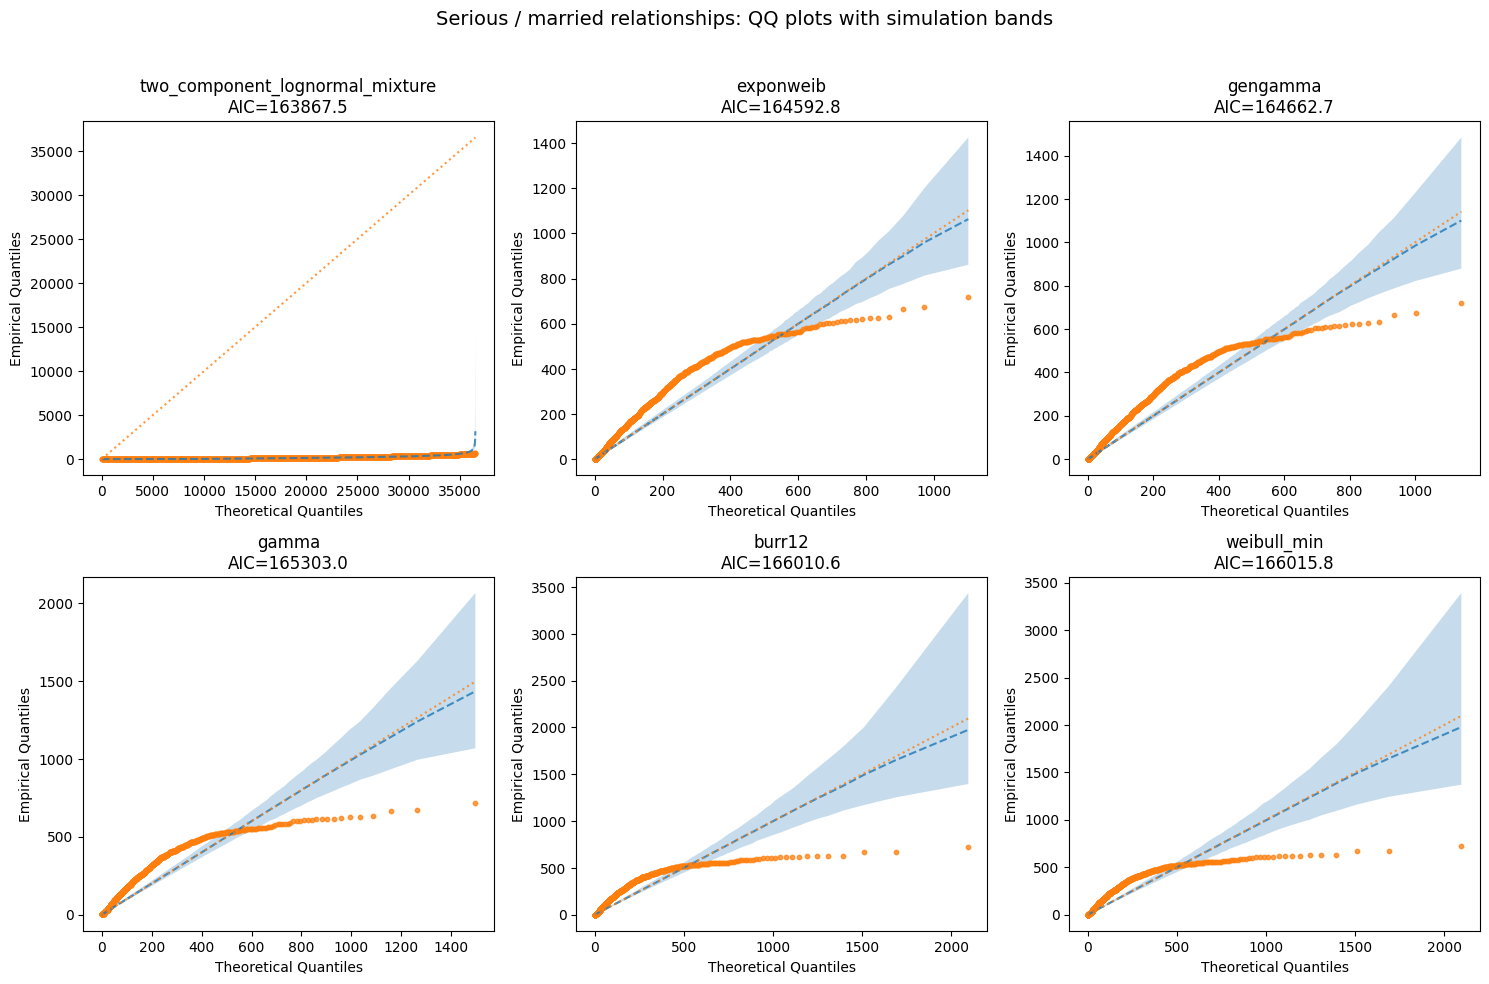

Objects created:
- all_distribution_fit_tables: all candidate fits by group and duration variable
- selected_distribution_fit_tables: candidate fits for the best duration variable in each group


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats, optimize
from IPython.display import display

# Expected input from the previous duration-building section:
#   rel_duration_df with columns: relation_group, relation_code, weight, duration_months_refined
# Optional alternative duration columns are tried if present.

DURATION_COLS_TO_TRY = ['duration_months_refined', 'duration_months_calendar']
GROUP_ORDER = ['casual', 'serious_married']
GROUP_TITLES = {
    'casual': 'Casual relationships',
    'serious_married': 'Serious / married relationships',
}

# QQ simulation settings. Increase n_sim for smoother bands if it runs quickly on your machine.
QQ_N_SIM = 2_000
QQ_MAX_N = 1_500       # caps points per QQ plot so simulation bands do not become too slow
RANDOM_SEED = 12345
rng = np.random.default_rng(RANDOM_SEED)


# -----------------------------
# Basic data handling
# -----------------------------

def clean_fit_data(data, group, duration_col):
    g = data[data['relation_group'] == group].copy()
    if len(g) == 0:
        return g, np.array([]), np.array([])
    x = pd.to_numeric(g[duration_col], errors='coerce').to_numpy(dtype=float)
    w = pd.to_numeric(g['weight'], errors='coerce').to_numpy(dtype=float)
    ok = np.isfinite(x) & (x > 0) & np.isfinite(w) & (w > 0)
    return g.loc[ok].copy(), x[ok], w[ok]


def scaled_weights(w):
    w = np.asarray(w, dtype=float)
    return w * (len(w) / np.sum(w))


def weighted_mean(x, w):
    x, w = np.asarray(x, dtype=float), np.asarray(w, dtype=float)
    return float(np.sum(w * x) / np.sum(w))


def weighted_var(x, w):
    x, w = np.asarray(x, dtype=float), np.asarray(w, dtype=float)
    mu = weighted_mean(x, w)
    return float(np.sum(w * (x - mu) ** 2) / np.sum(w))


def weighted_quantile(x, q, w=None):
    x = np.asarray(x, dtype=float)
    if w is None:
        w = np.ones_like(x, dtype=float)
    else:
        w = np.asarray(w, dtype=float)
    ok = np.isfinite(x) & np.isfinite(w) & (w > 0)
    x, w = x[ok], w[ok]
    if len(x) == 0:
        return np.nan
    order = np.argsort(x)
    x, w = x[order], w[order]
    cw = np.cumsum(w) / np.sum(w)
    return float(np.interp(q, cw, x))


def weighted_resample(x, w, n, rng):
    x = np.asarray(x, dtype=float)
    w = np.asarray(w, dtype=float)
    p = w / np.sum(w)
    idx = rng.choice(np.arange(len(x)), size=n, replace=True, p=p)
    return x[idx]


# -----------------------------
# Candidate distributions and custom mixtures
# -----------------------------

SCIPY_DISTRIBUTIONS = [
    # distribution_name, scipy.stats object, number_of_parameters_when_floc0
    ('expon', stats.expon, 1),
    ('gamma', stats.gamma, 2),
    ('weibull_min', stats.weibull_min, 2),
    ('lognorm', stats.lognorm, 2),
    ('fisk_loglogistic', stats.fisk, 2),
    ('invgauss', stats.invgauss, 2),
    ('burr12', stats.burr12, 3),
    ('gengamma', stats.gengamma, 3),
    ('exponweib', stats.exponweib, 3),  # with loc fixed, shape a/c + scale
]


def params_to_string(name, params):
    if name == 'two_component_lognormal_mixture':
        return '; '.join(
            f"c{i+1}: pi={pi:.3g}, median={np.exp(mu):.3g}, sigma_log={sig:.3g}"
            for i, (pi, mu, sig) in enumerate(zip(params['pi'], params['mu'], params['sigma']))
        )
    if name == 'status_lognormal_mixture':
        return '; '.join(
            f"relation_code={code}: pi={pi:.3g}, median={np.exp(mu):.3g}, sigma_log={sig:.3g}"
            for code, pi, mu, sig in zip(params['rel_codes'], params['pi'], params['mu'], params['sigma'])
        )
    return ', '.join(f'{v:.6g}' for v in params)


def mixture_lognormal_pdf(x, params):
    x = np.asarray(x, dtype=float)
    y = np.zeros_like(x, dtype=float)
    for pi, mu, sigma in zip(params['pi'], params['mu'], params['sigma']):
        y += pi * stats.lognorm.pdf(x, s=sigma, loc=0, scale=np.exp(mu))
    return y


def mixture_lognormal_rvs(params, size, rng):
    comp = rng.choice(np.arange(len(params['pi'])), size=size, replace=True, p=params['pi'])
    out = np.empty(size, dtype=float)
    for j in range(len(params['pi'])):
        m = comp == j
        out[m] = rng.lognormal(mean=params['mu'][j], sigma=params['sigma'][j], size=np.sum(m))
    return out


def mixture_lognormal_ppf(probs, params):
    probs = np.asarray(probs, dtype=float)
    xmax = max(10.0, np.exp(np.max(params['mu']) + 8 * np.max(params['sigma'])))
    grid = np.linspace(1e-9, xmax, 6000)
    cdf = np.zeros_like(grid)
    for pi, mu, sigma in zip(params['pi'], params['mu'], params['sigma']):
        cdf += pi * stats.lognorm.cdf(grid, s=sigma, loc=0, scale=np.exp(mu))
    return np.interp(probs, cdf, grid)


def fit_lognormal_mixture_weighted(x, w, k=2, n_iter=500, tol=1e-7):
    # Weighted EM on log(duration), i.e. a mixture of lognormal components.
    z = np.log(np.asarray(x, dtype=float))
    w = np.asarray(w, dtype=float)
    mu = np.array([weighted_quantile(z, q, w) for q in np.linspace(0.25, 0.75, k)])
    sigma = np.repeat(max(np.sqrt(weighted_var(z, w)), 0.25), k).astype(float)
    pi = np.repeat(1 / k, k).astype(float)

    prev_ll = -np.inf
    for _ in range(n_iter):
        comp = np.column_stack([pi[j] * stats.norm.pdf(z, loc=mu[j], scale=sigma[j]) for j in range(k)])
        denom = np.maximum(comp.sum(axis=1), 1e-300)
        resp = comp / denom[:, None]
        wr = resp * w[:, None]
        Nk = np.maximum(wr.sum(axis=0), 1e-12)
        pi = Nk / np.sum(w)
        mu = (wr * z[:, None]).sum(axis=0) / Nk
        sigma = np.sqrt(np.maximum((wr * (z[:, None] - mu) ** 2).sum(axis=0) / Nk, 1e-8))
        ll = np.sum(scaled_weights(w) * np.log(np.maximum(mixture_lognormal_pdf(x, {'pi': pi, 'mu': mu, 'sigma': sigma}), 1e-300)))
        if abs(ll - prev_ll) < tol:
            break
        prev_ll = ll

    order = np.argsort(mu)
    return {'pi': pi[order], 'mu': mu[order], 'sigma': sigma[order]}


def fit_status_lognormal_mixture(g, duration_col):
    # Serious/married is usually heterogeneous. This mixture uses the relation_code split
    # when available, rather than forcing married/live-in and steady partners to share one shape.
    if 'relation_code' not in g.columns:
        return None
    pieces = []
    for rel_code in sorted(pd.Series(g['relation_code']).dropna().unique()):
        sub = g[g['relation_code'] == rel_code]
        if len(sub) < 5:
            continue
        x = pd.to_numeric(sub[duration_col], errors='coerce').to_numpy(dtype=float)
        w = pd.to_numeric(sub['weight'], errors='coerce').to_numpy(dtype=float)
        ok = np.isfinite(x) & (x > 0) & np.isfinite(w) & (w > 0)
        x, w = x[ok], w[ok]
        if len(x) < 5:
            continue
        lx = np.log(x)
        pieces.append({
            'rel_code': int(rel_code),
            'pi_raw': np.sum(w),
            'mu': weighted_mean(lx, w),
            'sigma': max(np.sqrt(weighted_var(lx, w)), 1e-6),
        })
    if len(pieces) < 2:
        return None
    total = sum(p['pi_raw'] for p in pieces)
    return {
        'rel_codes': [p['rel_code'] for p in pieces],
        'pi': np.array([p['pi_raw'] / total for p in pieces], dtype=float),
        'mu': np.array([p['mu'] for p in pieces], dtype=float),
        'sigma': np.array([p['sigma'] for p in pieces], dtype=float),
    }


def model_pdf(distribution_name, x, fitted_params):
    if distribution_name in ['two_component_lognormal_mixture', 'status_lognormal_mixture']:
        return mixture_lognormal_pdf(x, fitted_params)
    dist = fitted_params['dist']
    params = fitted_params['params']
    return dist.pdf(x, *params)


def model_ppf(distribution_name, probs, fitted_params):
    if distribution_name in ['two_component_lognormal_mixture', 'status_lognormal_mixture']:
        return mixture_lognormal_ppf(probs, fitted_params)
    return fitted_params['dist'].ppf(probs, *fitted_params['params'])


def model_rvs(distribution_name, fitted_params, size, rng):
    if distribution_name in ['two_component_lognormal_mixture', 'status_lognormal_mixture']:
        return mixture_lognormal_rvs(fitted_params, size=size, rng=rng)
    return fitted_params['dist'].rvs(*fitted_params['params'], size=size, random_state=rng)


# -----------------------------
# Fitting and AIC
# -----------------------------

def weighted_loglik(x, w, pdf_values):
    return float(np.sum(scaled_weights(w) * np.log(np.maximum(pdf_values, 1e-300))))


def empirical_histogram(x, w, max_months, n_bins):
    keep = x <= max_months
    x_plot, w_plot = x[keep], w[keep]
    bins = np.linspace(0, max_months, n_bins + 1)
    counts, edges = np.histogram(x_plot, bins=bins, weights=w_plot)
    widths = np.diff(edges)
    centers = edges[:-1] + widths / 2
    density = counts / (np.sum(counts) * widths)
    return centers, density, widths, edges, counts


def fit_all_candidates(g, x, w, duration_col, group):
    rows = []
    for distribution_name, dist, k in SCIPY_DISTRIBUTIONS:
        try:
            # Fix loc=0 because duration cannot be negative and allowing location shifts made
            # several fits visually worse/less interpretable for these month-duration data.
            params = dist.fit(x, floc=0)
            fitted_params = {'dist': dist, 'params': params}
            pdf_x = model_pdf(distribution_name, x, fitted_params)
            ll = weighted_loglik(x, w, pdf_x)
            rows.append({
                'group': group,
                'duration_variable': duration_col,
                'distribution_name': distribution_name,
                'distribution_parameters_values': params_to_string(distribution_name, params),
                'AIC': 2 * k - 2 * ll,
                'n_parameters': k,
                'weighted_log_likelihood': ll,
                'fitted_params': fitted_params,
            })
        except Exception as e:
            print(f'{distribution_name} failed for {group}, {duration_col}: {e}')

    # Flexible lognormal mixture.
    try:
        params = fit_lognormal_mixture_weighted(x, w, k=2)
        ll = weighted_loglik(x, w, mixture_lognormal_pdf(x, params))
        rows.append({
            'group': group,
            'duration_variable': duration_col,
            'distribution_name': 'two_component_lognormal_mixture',
            'distribution_parameters_values': params_to_string('two_component_lognormal_mixture', params),
            'AIC': 2 * 5 - 2 * ll,
            'n_parameters': 5,
            'weighted_log_likelihood': ll,
            'fitted_params': params,
        })
    except Exception as e:
        print(f'two_component_lognormal_mixture failed for {group}, {duration_col}: {e}')

    # Extra serious/married mixture by relation_code if possible.
    if group == 'serious_married':
        try:
            params = fit_status_lognormal_mixture(g, duration_col)
            if params is not None:
                ll = weighted_loglik(x, w, mixture_lognormal_pdf(x, params))
                # k = per component mu+sigma, plus k-1 mixture weights.
                k = 2 * len(params['pi']) + (len(params['pi']) - 1)
                rows.append({
                    'group': group,
                    'duration_variable': duration_col,
                    'distribution_name': 'status_lognormal_mixture',
                    'distribution_parameters_values': params_to_string('status_lognormal_mixture', params),
                    'AIC': 2 * k - 2 * ll,
                    'n_parameters': k,
                    'weighted_log_likelihood': ll,
                    'fitted_params': params,
                })
        except Exception as e:
            print(f'status_lognormal_mixture failed for {group}, {duration_col}: {e}')

    out = pd.DataFrame(rows)
    if len(out):
        out = out.sort_values('AIC').reset_index(drop=True)
        out['delta_AIC'] = out['AIC'] - out['AIC'].min()
    return out


if 'rel_duration_df' not in globals():
    raise NameError('rel_duration_df was not found. Run the duration data-building cell before this one.')

all_distribution_fit_tables = {}
selected_distribution_fit_tables = {}

for group in GROUP_ORDER:
    group_tables = []
    for duration_col in DURATION_COLS_TO_TRY:
        if duration_col not in rel_duration_df.columns:
            continue
        g, x, w = clean_fit_data(rel_duration_df, group, duration_col)
        if len(x) < 10:
            continue
        fit_table = fit_all_candidates(g, x, w, duration_col, group)
        if len(fit_table):
            group_tables.append(fit_table)

    if group_tables:
        all_group = pd.concat(group_tables, ignore_index=True).sort_values('AIC').reset_index(drop=True)
        all_group['delta_AIC_overall'] = all_group['AIC'] - all_group['AIC'].min()
        all_distribution_fit_tables[group] = all_group
        # For plots/QQ, use the best duration variable and its candidate fits.
        best_duration_col = all_group.iloc[0]['duration_variable']
        selected_distribution_fit_tables[group] = all_group[all_group['duration_variable'] == best_duration_col].sort_values('AIC').reset_index(drop=True)


# Output tables with exactly the requested key columns, printed separately by group.
for group in GROUP_ORDER:
    if group not in selected_distribution_fit_tables:
        print(f'No fitted distributions available for {group}.')
        continue
    table = selected_distribution_fit_tables[group][[
        'distribution_name',
        'distribution_parameters_values',
        'AIC',
    ]].copy()
    table['AIC'] = table['AIC'].round(2)
    print(f'\n{GROUP_TITLES[group]} — fitted distributions ranked by AIC')
    print(f"Duration variable used: {selected_distribution_fit_tables[group].iloc[0]['duration_variable']}")
    display(table)


# -----------------------------
# Histogram bars for the data plus lower-alpha fitted distribution lines
# -----------------------------

for group in GROUP_ORDER:
    if group not in selected_distribution_fit_tables:
        continue

    fit_table = selected_distribution_fit_tables[group]
    duration_col = fit_table.iloc[0]['duration_variable']
    g, x, w = clean_fit_data(rel_duration_df, group, duration_col)

    if group == 'casual':
        max_months = min(max(weighted_quantile(x, 0.99, w), 12),48)
        n_bins = 32
    else:
        max_months = min(max(weighted_quantile(x, 0.99, w), 60), 600)
        n_bins = 40

    centers, density, widths, edges, counts = empirical_histogram(x, w, max_months=max_months, n_bins=n_bins)
    grid = np.linspace(max_months / 1000, max_months, 800)

    fig, ax = plt.subplots(figsize=(10, 5.5))
    ax.bar(centers, density, width=widths, align='center', alpha=0.35, label='Weighted empirical data')

    for _, row in fit_table.head(8).iterrows():
        y = model_pdf(row['distribution_name'], grid, row['fitted_params'])
        ax.plot(
            grid, y,
            linewidth=1.8,
            alpha=0.45,
            label=f"{row['distribution_name']} (AIC={row['AIC']:.1f})",
        )

    ax.set_title(f"{GROUP_TITLES[group]}: data histogram with fitted distributions")
    ax.set_xlabel('Relationship duration, months')
    ax.set_ylabel('Density')
    ax.set_xlim(0, max_months)
    ax.grid(True, alpha=0.25)
    ax.legend(fontsize=8)
    plt.tight_layout()
    plt.show()


# -----------------------------
# QQ plots with simulation bands, similar to the example image
# -----------------------------

def plot_qq_simulation_bands(group, fit_table, n_sim=QQ_N_SIM, max_n=QQ_MAX_N):
    duration_col = fit_table.iloc[0]['duration_variable']
    g, x, w = clean_fit_data(rel_duration_df, group, duration_col)
    if len(x) < 10:
        print(f'Not enough data for QQ plot: {group}')
        return

    # Use a weighted resample if there are many records, so the QQ envelopes remain tractable.
    n = min(len(x), max_n)
    data = weighted_resample(x, w, n, rng) if len(x) > n else x.copy()
    sorted_data = np.sort(data)
    probs = (np.arange(1, n + 1) - 0.5) / n

    qq_models = fit_table.head(6).reset_index(drop=True)
    ncols = 3
    nrows = int(np.ceil(len(qq_models) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(15, 4.8 * nrows))
    axes = np.array(axes).reshape(-1)

    for ax, (_, row) in zip(axes, qq_models.iterrows()):
        name = row['distribution_name']
        fitted_params = row['fitted_params']
        theoretical_q = model_ppf(name, probs, fitted_params)

        ok = np.isfinite(theoretical_q)
        theoretical_q = theoretical_q[ok]
        sorted_data_plot = sorted_data[ok]
        probs_plot = probs[ok]
        n_plot = len(theoretical_q)

        sim_quantiles = np.empty((n_sim, n_plot), dtype=float)
        for i in range(n_sim):
            sim_sample = model_rvs(name, fitted_params, size=n, rng=rng)
            # Durations are recorded in months, so rounding simulated values makes the
            # envelope comparable to the discrete empirical points.
            sim_sample = np.round(sim_sample)
            sim_sample = np.sort(sim_sample[np.isfinite(sim_sample)])
            if len(sim_sample) < n:
                # Rare fallback if a distribution generates non-finite values.
                sim_sample = np.pad(sim_sample, (0, n - len(sim_sample)), constant_values=np.nan)
            sim_quantiles[i, :] = sim_sample[ok]

        lower = np.nanpercentile(sim_quantiles, 2.5, axis=0)
        upper = np.nanpercentile(sim_quantiles, 97.5, axis=0)
        median = np.nanpercentile(sim_quantiles, 50, axis=0)

        ax.fill_between(theoretical_q, lower, upper, alpha=0.25)
        ax.plot(theoretical_q, median, linestyle='--', linewidth=1.5, alpha=0.8)
        ax.scatter(theoretical_q, sorted_data_plot, s=10, alpha=0.75)
        ax.plot(theoretical_q, theoretical_q, linestyle=':', linewidth=1.5, alpha=0.8)
        ax.set_title(f"{name}\nAIC={row['AIC']:.1f}")
        ax.set_xlabel('Theoretical Quantiles')
        ax.set_ylabel('Empirical Quantiles')

    for ax in axes[len(qq_models):]:
        ax.axis('off')

    fig.suptitle(f"{GROUP_TITLES[group]}: QQ plots with simulation bands", y=1.02, fontsize=14)
    plt.tight_layout()
    plt.show()


for group in GROUP_ORDER:
    if group in selected_distribution_fit_tables:
        plot_qq_simulation_bands(group, selected_distribution_fit_tables[group])

print('Objects created:')
print('- all_distribution_fit_tables: all candidate fits by group and duration variable')
print('- selected_distribution_fit_tables: candidate fits for the best duration variable in each group')


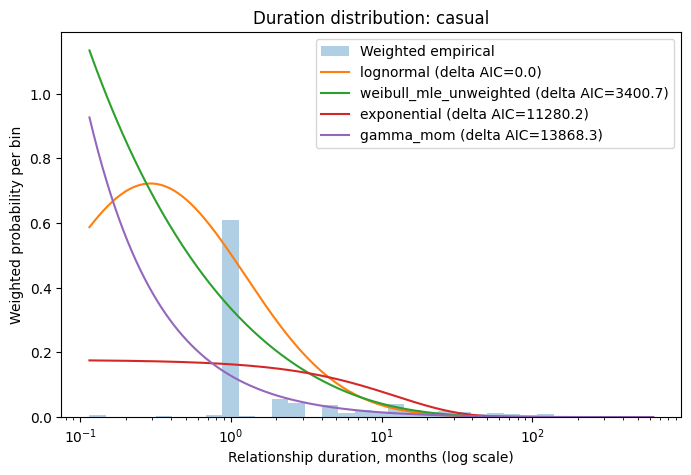

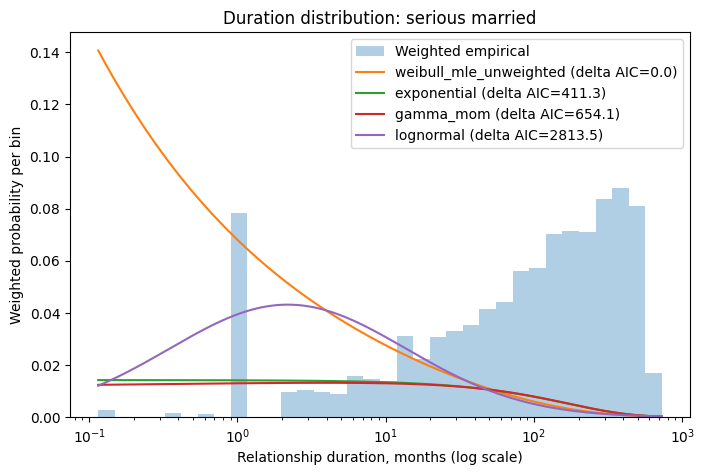

In [10]:
# -----------------------------
# Plot separate duration distributions for casual and serious/married relations
# -----------------------------

def plot_duration_distribution(data, group, duration_col='duration_months_refined', max_months=None):
    g = data[data['relation_group'] == group].copy()
    if len(g) == 0:
        print(f"No records for {group}")
        return

    x = g[duration_col].astype(float).to_numpy()
    w = g['weight'].astype(float).to_numpy()
    valid = np.isfinite(x) & (x > 0) & np.isfinite(w) & (w > 0)
    x = x[valid]
    w = w[valid]
    if max_months is not None:
        keep = x <= max_months
        x = x[keep]
        w = w[keep]

    # Log-spaced bins show both short casual partnerships and long serious partnerships.
    xmin = max(0.1, np.nanmin(x))
    xmax = max(np.nanmax(x), xmin * 1.1)
    bins = np.geomspace(xmin, xmax, 35)

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.hist(x, bins=bins, weights=w / np.sum(w), alpha=0.35, density=False, label='Weighted empirical')

    fits = duration_fits.get(group, pd.DataFrame())
    if len(fits):
        grid = np.geomspace(xmin, xmax, 400)
        # Convert fitted PDF to approximately the same vertical scale as the probability histogram.
        # For unequal log bins, probability mass per bin is roughly pdf(x) * local bin width.
        median_bin_width = np.median(np.diff(bins))
        for _, row in fits.head(4).iterrows():
            y = safe_pdf(row['model'], grid, row['params']) * median_bin_width
            ax.plot(grid, y, label=f"{row['model']} (delta AIC={row['delta_aic']:.1f})")

    ax.set_xscale('log')
    ax.set_xlabel('Relationship duration, months (log scale)')
    ax.set_ylabel('Weighted probability per bin')
    ax.set_title(f"Duration distribution: {group.replace('_', ' ')}")
    ax.legend()
    plt.show()

if len(rel_duration_df):
    plot_duration_distribution(rel_duration_df, 'casual')
    plot_duration_distribution(rel_duration_df, 'serious_married')


In [ ]:
# -----------------------------
# Compare calendar-month versus refined duration variables
# -----------------------------

# This checks how much the short-duration r1mtha/r1mthb questions change the distribution.
# In most long relationships the refined and calendar variables are identical; for very recent
# relationships the refined variable can place the duration below one month.

if len(rel_duration_df):
    for group in ['casual', 'serious_married']:
        g = rel_duration_df[rel_duration_df['relation_group'] == group].copy()
        if len(g) == 0:
            continue
        fig, ax = plt.subplots(figsize=(8, 5))
        for col in ['duration_months_calendar', 'duration_months_refined']:
            x = g[col].astype(float).to_numpy()
            w = g['weight'].astype(float).to_numpy()
            valid = np.isfinite(x) & (x > 0) & np.isfinite(w) & (w > 0)
            x = x[valid]
            w = w[valid]
            order = np.argsort(x)
            x = x[order]
            cw = np.cumsum(w[order]) / np.sum(w)
            ax.step(x, cw, where='post', label=col)
        ax.set_xscale('log')
        ax.set_xlabel('Relationship duration, months (log scale)')
        ax.set_ylabel('Weighted cumulative probability')
        ax.set_title(f"Calendar vs refined duration: {group.replace('_', ' ')}")
        ax.legend()
        plt.show()


In [ ]:
# -----------------------------
# Export empirical CDF/PMF-style objects for simulation use
# -----------------------------

# These arrays can be sampled directly when you construct synthetic partnership durations.
# Example: np.random.choice(values, p=probabilities)

relationship_duration_empirical = {}

if len(rel_duration_df):
    for group in ['casual', 'serious_married']:
        g = rel_duration_df[rel_duration_df['relation_group'] == group]
        if len(g) == 0:
            continue
        # Round to 0.25 months to retain sub-month information without too many support points.
        vals = np.maximum(0.25, np.round(g['duration_months_refined'].astype(float).to_numpy() * 4) / 4)
        w = g['weight'].astype(float).to_numpy()
        tmp = pd.DataFrame({'duration_months': vals, 'weight': w})
        pmf = tmp.groupby('duration_months', as_index=False)['weight'].sum()
        pmf['probability'] = pmf['weight'] / pmf['weight'].sum()
        relationship_duration_empirical[group] = pmf[['duration_months', 'probability']]

        print(f"\nEmpirical sampling distribution for {group}:")
        display(relationship_duration_empirical[group].head(20))

    # Fitted distribution parameters are in duration_fits.
    print("\nBest-fit model by AIC:")
    for group, fits in duration_fits.items():
        if len(fits):
            print(group, '->', fits.iloc[0]['model'], fits.iloc[0]['params'])
